[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_10/MFM_ch10_seminar/MFM_ch10_seminar.ipynb)

# Modelling Financial Markets — Seminar 10: Market Microstructure

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Core exercises: A1–A2, B1–B4, C2; extension packs: A3–A10, B5–B8, C1, C3.

> Quantlet `MFM_ch10_seminar`: student version of the Seminar 10 notebook. Solved exercises (A1, A3, A5, A7, A9, B1, B2, B4, B6, B8) are shown with code and output; the proposed exercises (A2, A4, A6, A8, A10, B3, B5, B7, C1, C2, C3) are not solved here (an empty code cell where they need code).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
GROUP_COL = {'US': MainBlue, 'BVB': IDAred, 'Crypto': Amber}

HERE = '.'
SEED = 42
START2 = '2024-09-19'
START10 = '2016-09-19'
B_BOOT = 1000



def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """A single legend for a multi-panel figure, below the figure."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## Data

- SPY 5-minute bars, regular session (09:30–16:00 New York time), October 2020 – September 2026; Bitcoin 5-minute bars (UTC), September 2024 – September 2026.
- Daily open, high, low, close and volume for US stocks, Bucharest Stock Exchange (BVB) stocks and crypto-assets; prices adjusted for dividends and splits.
- BVB traded values converted from lei to USD at the reference rate of the National Bank of Romania (BNR); crypto traded values are in USD.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# key -> (symbol, label, group)
ASSETS = {
    'SPY': ('SPY.US', 'SPY', 'US'), 'AAPL': ('AAPL.US', 'Apple', 'US'), 'MSFT': ('MSFT.US', 'Microsoft', 'US'),
    'NVDA': ('NVDA.US', 'NVIDIA', 'US'), 'JPM': ('JPM.US', 'JPMorgan', 'US'), 'GME': ('GME.US', 'GameStop', 'US'),
    'MSTR': ('MSTR.US', 'Strategy', 'US'),
    'TLV': ('TLV.RO', 'Banca Transilvania', 'BVB'), 'SNP': ('SNP.RO', 'OMV Petrom', 'BVB'),
    'H2O': ('H2O.RO', 'Hidroelectrica', 'BVB'), 'BRD': ('BRD.RO', 'BRD', 'BVB'), 'SNG': ('SNG.RO', 'Romgaz', 'BVB'),
    'SNN': ('SNN.RO', 'Nuclearelectrica', 'BVB'), 'TGN': ('TGN.RO', 'Transgaz', 'BVB'),
    'EL': ('EL.RO', 'Electrica', 'BVB'), 'DIGI': ('DIGI.RO', 'Digi', 'BVB'), 'TEL': ('TEL.RO', 'Transelectrica', 'BVB'),
    'TVBETETF': ('TVBETETF.RO', 'BET ETF', 'BVB'),
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'Crypto'), 'ETH': ('ETH-USD.CC', 'Ethereum', 'Crypto'),
    'SOL': ('SOL-USD.CC', 'Solana', 'Crypto'), 'XRP': ('XRP-USD.CC', 'XRP', 'Crypto'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'Crypto'), 'ADA': ('ADA-USD.CC', 'Cardano', 'Crypto'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'Crypto'),
}
GROUPS = {g: [k for k, v in ASSETS.items() if v[2] == g] for g in ('US', 'BVB', 'Crypto')}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# large adjustment events that are cash dividends, not splits (issuer announcement):
#   SNN.RO 2018-12-21: gross dividend of 1.61 lei per share, ex-date 21 December 2018
#   (https://www.nuclearelectrica.ro/wp-content/uploads/2018/12/SNN_Comunicat-plata-dividende-suplimentare_EN.pdf)
CASH_DIVIDENDS = {'SNN.RO': ['2018-12-21']}

_CACHE = {}


def read_market(symbol):
    """Read the daily price file of one symbol, from a local copy or from the GitHub repository."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def read_reference_rate(currency='USD', start='2014-01-01', end=END):
    """Official RON reference rate (BNR yearly XML archives)."""
    key = ('REF', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'rate']).drop_duplicates('date').set_index('date')['rate']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def _clean(key, d):
    d = d[(d['high'] > d['low']) & (d['volume'].fillna(0) > 0)]
    if ASSETS[key][2] != 'Crypto':
        d = d[d.index.dayofweek < 5]
        # isolated bad ticks: adjusted price more than twice / less than half the local median (21 days)
        med = d['adjusted_close'].rolling(21, center=True, min_periods=5).median()
        d = d[np.abs(np.log(d['adjusted_close'] / med)) < np.log(2)]
    return d


def ohlc(key, start='2016-09-19', end=END):
    """Open, high, low, close scaled by the adjustment factor of the adjusted price (dividends and splits)."""
    d = read_market(ASSETS[key][0]).loc[start:end].copy()
    f = d['adjusted_close'] / d['close']
    for c in ['open', 'high', 'low', 'close']:
        d[c] = d[c] * f
    return _clean(key, d)[['open', 'high', 'low', 'close', 'volume']]


def split_adjusted_close(d, symbol=None):
    """Close price adjusted ONLY for splits and bonus shares (same basis as the volume in number of shares);
    the large cash dividends in CASH_DIVIDENDS are not treated as splits."""
    k = (d['close'].shift(1) / d['close']) / (d['adjusted_close'].shift(1) / d['adjusted_close'])
    k = k.where(np.abs(np.log(k)) > 0.15, 1.0).fillna(1.0)      # split days: the split ratio
    for day in CASH_DIVIDENDS.get(symbol, []):
        k.loc[k.index == pd.Timestamp(day)] = 1.0
    back = k[::-1].cumprod()[::-1].shift(-1).fillna(1.0)          # product of the splits after each day
    return d['close'] / back


def returns(key, start='2016-09-19', end=END):
    """Daily log returns from the adjusted price (days without trading dropped)."""
    d = read_market(ASSETS[key][0]).loc[start:end]
    d = _clean(key, d)
    return np.log(d['adjusted_close']).diff().dropna().rename(key)


def dollar_volume(key, start='2016-09-19', end=END):
    """Daily traded value, in USD."""
    d = read_market(ASSETS[key][0]).loc[:end]
    grp = ASSETS[key][2]
    if grp == 'Crypto':
        dv = d['volume']                                          # already in USD
    else:
        dv = split_adjusted_close(d, ASSETS[key][0]) * d['volume']
        if grp == 'BVB':                                          # RON -> USD at the BNR reference rate
            fx = read_reference_rate('USD', start='2014-01-01', end=end)
            dv = dv / fx.reindex(dv.index).ffill()
    d = _clean(key, d.assign(dv=dv))
    return d['dv'].loc[start:end].dropna().rename(key)


def intraday_spy():
    """SPY 5-minute bars, regular session (09:30-15:55 = bar start), complete days only (78 bars)."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    t = d['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None)
    d = d.assign(t=t, date=t.dt.normalize(), tod=t.dt.strftime('%H:%M')).drop(columns='datetime_utc')
    d = d[(d['tod'] >= '09:30') & (d['tod'] <= '15:55')]
    n = d.groupby('date').size()
    d = d[d['date'].isin(n[n == 78].index)].set_index('t').sort_index()
    d['r'] = np.log(d['close']).groupby(d['date']).diff()
    first = d['tod'] == '09:30'
    d.loc[first, 'r'] = np.log(d.loc[first, 'close'] / d.loc[first, 'open'])   # first bar: from the open
    d['dv'] = d['close'] * d['volume']
    return d


def intraday_btc():
    """Bitcoin 5-minute bars (UTC), 24 hours a day; volume is not used (missing on many bars)."""
    fname = 'intraday/BTC-USD.CC_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d = d.set_index('datetime_utc').sort_index()
    d = d[~d.index.duplicated()]
    d['date'] = d.index.normalize()
    d['r'] = np.log(d['close']).diff()
    gap = d.index.to_series().diff() != pd.Timedelta('5min')
    d.loc[gap, 'r'] = np.nan                                       # no returns across missing bars
    return d

## Estimators and models

- `roll_spread`, `cs_spread`, `ar_terms`, `edge_spread`, `amihud`: spread and illiquidity measures; `roll_mc`: Monte Carlo of the Roll model.
- `price_discovery`: information shares from a vector error-correction model (VECM); `pin_loglik`: the likelihood of the probability of informed trading (PIN) in stable form.
- `walk_book`, `zi_simulate`: order book execution and a simulated order book.
- `gm_quotes`, `gm_simulate`, `kyle`, `ac_trajectory`, `ac_frontier`: Glosten–Milgrom, Kyle and Almgren–Chriss.

In [ ]:
def roll_spread(close):
    """Roll relative spread from the first-order autocovariance of log returns; NaN if the covariance is positive."""
    r = np.log(np.asarray(close, float))
    dp = np.diff(r)
    c = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return (2 * np.sqrt(-c) if c < 0 else np.nan), c


def cs_spread(high, low, close=None):
    """Corwin-Schultz estimator for each pair of consecutive periods (negative values set to 0).
    With close (daily data): the overnight adjustment of Corwin and Schultz (2012): if the low of day t+1 is above
    the close of day t, the high and low of t+1 are lowered by the difference; if the high of t+1 is below the close
    of t, both are raised by the difference. Intraday bars of the same session are not adjusted."""
    H, L = np.asarray(high, float), np.asarray(low, float)
    h0, l0, h1, l1 = H[:-1], L[:-1], H[1:].copy(), L[1:].copy()
    if close is not None:
        c0 = np.asarray(close, float)[:-1]
        up = l1 > c0
        d = np.where(up, l1 - c0, 0.0)
        h1, l1 = h1 - d, l1 - d
        dn = h1 < c0
        d = np.where(dn, c0 - h1, 0.0)
        h1, l1 = h1 + d, l1 + d
    beta = np.log(h0 / l0) ** 2 + np.log(h1 / l1) ** 2
    gamma = np.log(np.maximum(h0, h1) / np.minimum(l0, l1)) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    return np.clip(2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha)), 0, None)


def ar_terms(close, high, low):
    """Abdi-Ranaldo terms: 4 (c_t - eta_t)(c_t - eta_{t+1}); their mean estimates s^2."""
    c = np.log(np.asarray(close, float))
    eta = (np.log(np.asarray(high, float)) + np.log(np.asarray(low, float))) / 2
    return 4 * (c[:-1] - eta[:-1]) * (c[:-1] - eta[1:])


def ar_spread(close, high, low):
    """Abdi-Ranaldo relative spread: sqrt(max(mean of the terms, 0))."""
    m = np.mean(ar_terms(close, high, low))
    return np.sqrt(max(m, 0.0)), m


def edge_spread(open_, high, low, close, sign=True):
    """EDGE (Ardia, Guidotti and Kroencke, 2024, JFE 161, 103916): relative spread from OHLC prices.
    Follows the authors' reference implementation (bidask package, MIT licence). sign=True returns the signed
    estimate; for averages over several windows, each negative window estimate is set to zero before averaging."""
    o, h, l, c = (np.log(np.asarray(x, float)) for x in (open_, high, low, close))
    if len(o) < 3:
        return np.nan
    m = (h + l) / 2.
    h1, l1, c1, m1 = h[:-1], l[:-1], c[:-1], m[:-1]
    o, h, l, c, m = o[1:], h[1:], l[1:], c[1:], m[1:]
    r1, r2, r3, r4, r5 = m - o, o - m1, m - c1, c1 - m1, o - c1
    tau = np.where(np.isnan(h) | np.isnan(l) | np.isnan(c1), np.nan, (h != l) | (l != c1))
    po1 = tau * np.where(np.isnan(o) | np.isnan(h), np.nan, o != h)
    po2 = tau * np.where(np.isnan(o) | np.isnan(l), np.nan, o != l)
    pc1 = tau * np.where(np.isnan(c1) | np.isnan(h1), np.nan, c1 != h1)
    pc2 = tau * np.where(np.isnan(c1) | np.isnan(l1), np.nan, c1 != l1)
    pt = np.nanmean(tau)
    po = np.nanmean(po1) + np.nanmean(po2)
    pc = np.nanmean(pc1) + np.nanmean(pc2)
    if np.nansum(tau) < 2 or po == 0 or pc == 0:
        return np.nan
    d1 = r1 - np.nanmean(r1) / pt * tau
    d3 = r3 - np.nanmean(r3) / pt * tau
    d5 = r5 - np.nanmean(r5) / pt * tau
    x1 = -4. / po * d1 * r2 - 4. / pc * d3 * r4
    x2 = -4. / po * d1 * r5 - 4. / pc * d5 * r4
    e1, e2 = np.nanmean(x1), np.nanmean(x2)
    v1, v2 = np.nanmean(x1 ** 2) - e1 ** 2, np.nanmean(x2 ** 2) - e2 ** 2
    vt = v1 + v2
    s2 = (v2 * e1 + v1 * e2) / vt if vt > 0 else (e1 + e2) / 2.
    s = np.sqrt(np.abs(s2))
    return float(s * np.sign(s2)) if sign else float(s)


def amihud(r, dv, scale=1e6):
    """Amihud illiquidity: mean |r| (basis points) per USD 1 million traded."""
    x = pd.concat([r.rename('r'), dv.rename('dv')], axis=1, join='inner').dropna()
    x = x[x['dv'] > 0]
    return float((1e4 * x['r'].abs() / (x['dv'] / scale)).mean())


def daily_estimates(d, overnight=True):
    """Spread estimators over a window of bars: overnight=True for daily data (Corwin-Schultz overnight
    adjustment), overnight=False for the intraday bars of one session."""
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'], d['close'] if overnight else None)
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return pd.Series(dict(cov=cov, roll=rs, cs=cs.mean(), ar2=ar2.mean()))


def roll_mc(c, sigma, T=78, R=20000, seed=42):
    """Harris (1990): simulate the Roll model (m_t a random walk with N(0, sigma^2) steps, q_t = +-1 with prob. 1/2)
    over T prices and compute the first-order autocovariance of the (demeaned) changes, as on real data."""
    rng = np.random.default_rng(seed)
    p = np.cumsum(rng.normal(0, sigma, (R, T)), axis=1) + c * np.where(rng.random((R, T)) < 0.5, 1, -1)
    dp = np.diff(p, axis=1)
    dm = dp - dp.mean(axis=1, keepdims=True)
    return (dm[:, 1:] * dm[:, :-1]).mean(axis=1)


def price_discovery(y, p=1):
    """Bivariate VECM with the cointegrating vector (1, -1) imposed: dy_t = a0 + alpha (y1 - y2)_{t-1} + sum Gamma_i dy_{t-i} + e_t.
    Returns alpha, the t statistics, the Gonzalo-Granger component share (normalised alpha_perp) and the bounds
    of the Hasbrouck information share (the two Cholesky orderings)."""
    y = np.asarray(y, float)
    dy = np.diff(y, axis=0)
    z = (y[:, 0] - y[:, 1])[:-1]
    X = np.array([[1.0, z[t]] + [v for i in range(1, p + 1) for v in dy[t - i]] for t in range(p, len(dy))])
    Y = dy[p:]
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    Om = U.T @ U / (len(U) - X.shape[1])
    alpha = B[1]
    se = np.sqrt(np.linalg.inv(X.T @ X)[1, 1] * np.diag(Om))
    ap = np.array([-alpha[1], alpha[0]])                       # alpha_perp: alpha' alpha_perp = 0
    cs = ap / ap.sum()
    psi = ap                                                    # common row of the long-run impact matrix (up to scale)
    IS = []
    for order in ([0, 1], [1, 0]):
        F = np.linalg.cholesky(Om[np.ix_(order, order)])
        v = (psi[order] @ F) ** 2 / (psi @ Om @ psi)
        IS.append(v[np.argsort(order)])
    IS = np.array(IS)
    return dict(alpha=alpha, t=alpha / se, cs=cs, is_lo=IS.min(axis=0), is_hi=IS.max(axis=0),
                corr=float(Om[0, 1] / np.sqrt(Om[0, 0] * Om[1, 1])), resid=U, n=len(U))


def pin_loglik(B, S, alpha, delta, mu, eb, es):
    """EKOP log-likelihood of a day with B buys and S sells, in the factorised form that avoids
    numerical overflow (Lin and Ke, 2011): ln L = -eb - es + B ln(mu + eb) + S ln(mu + es) - ln B! - ln S!
    + ln[(1 - alpha) xb^B xs^S + alpha delta e^-mu xb^B + alpha (1 - delta) e^-mu xs^S], xb = eb / (mu + eb)."""
    from scipy.special import gammaln, logsumexp
    lxb, lxs = np.log(eb / (mu + eb)), np.log(es / (mu + es))
    terms = [np.log(1 - alpha) + B * lxb + S * lxs, np.log(alpha * delta) - mu + B * lxb,
             np.log(alpha * (1 - delta)) - mu + S * lxs]
    base = -eb - es + B * np.log(mu + eb) + S * np.log(mu + es) - gammaln(B + 1) - gammaln(S + 1)
    return float(base + logsumexp(terms)), terms


def walk_book(asks, qty):
    """Market buy order of size qty against the sell offers asks = [(price, quantity), ...] in ascending order.
    Returns the fills, the volume-weighted average price and the remaining offers."""
    fills, left, rest = [], qty, []
    for p, q in asks:
        if left <= 0:
            rest.append((p, q))
            continue
        take = min(q, left)
        fills.append((p, take))
        left -= take
        if q > take:
            rest.append((p, q - take))
    vwap = sum(p * q for p, q in fills) / sum(q for _, q in fills)
    return fills, vwap, rest, left


def gm_quotes(theta, mu, vl, vh):
    """Ask and bid quotes: expected value conditional on a buy and on a sell, respectively.
    theta = P(V = vh), mu = share of informed traders; uninformed traders buy or sell with prob. 1/2."""
    pb_h, pb_l = mu + (1 - mu) / 2, (1 - mu) / 2               # P(buy | V = vh), P(buy | V = vl)
    th_b = pb_h * theta / (pb_h * theta + pb_l * (1 - theta))   # P(V = vh | buy)
    th_s = pb_l * theta / (pb_l * theta + pb_h * (1 - theta))   # P(V = vh | sell)
    return vl + th_b * (vh - vl), vl + th_s * (vh - vl), th_b, th_s


def gm_simulate(mu, vl=90.0, vh=110.0, v=110.0, n=60, seed=1):
    """A sequence of trades when the true value is v; the market maker learns from the order flow."""
    rng = np.random.default_rng(seed)
    theta, rows = 0.5, []
    for t in range(n):
        ask, bid, th_b, th_s = gm_quotes(theta, mu, vl, vh)
        informed = rng.random() < mu
        buy = (v == vh) if informed else (rng.random() < 0.5)
        rows.append(dict(t=t, ask=ask, bid=bid, theta=theta, buy=buy))
        theta = th_b if buy else th_s
    return pd.DataFrame(rows)


def kyle(sigma_v, sigma_u):
    """Kyle equilibrium: v ~ N(p0, sigma_v^2), noise-trader demand u ~ N(0, sigma_u^2).
    Informed strategy x = beta (v - p0), price p = p0 + lambda (x + u)."""
    beta = sigma_u / sigma_v
    lam = sigma_v / (2 * sigma_u)
    profit = sigma_v * sigma_u / 2
    return dict(beta=beta, lam=lam, profit=profit, post_var=sigma_v ** 2 / 2)


def ac_trajectory(X, T, N, sigma, eta, gamma, lam, eps=0.0):
    """Optimal liquidation trajectory (exact discrete-time formulas).
    X shares to sell in T days, N intervals; sigma = price volatility (USD / day^0.5);
    temporary impact h(v) = eps sgn + eta v; permanent impact g(v) = gamma v; lam = risk aversion."""
    tau = T / N
    eta_t = eta - gamma * tau / 2
    t = np.arange(N + 1) * tau
    if lam == 0:
        x = X * (1 - t / T)
    else:
        kt2 = lam * sigma ** 2 / eta_t                       # kappa_tilde^2
        kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    n = -np.diff(x)
    E = 0.5 * gamma * X ** 2 + eps * X + eta_t / tau * np.sum(n ** 2)
    V = sigma ** 2 * tau * np.sum(x[1:] ** 2)
    return t, x, E, V


def ac_frontier(X, T, N, sigma, eta, gamma, lams):
    """Efficient frontier (standard deviation, expected cost) for several risk aversions."""
    out = []
    for lam in lams:
        _, _, E, V = ac_trajectory(X, T, N, sigma, eta, gamma, lam)
        out.append((lam, E, np.sqrt(V)))
    return pd.DataFrame(out, columns=['lam', 'E', 'sd'])


def zi_simulate(n_events=300_000, L=40, rate_limit=1.0, rate_market=0.25, rate_cancel=0.025, n_ticks=4000, seed=7):
    """Limit orders (uniform over L ticks from the opposite quote), market orders and cancellations, all of one unit.
    Returns the (mid, spread) series and snapshots of the book."""
    rng = np.random.default_rng(seed)
    bid_q = np.zeros(n_ticks, int)
    ask_q = np.zeros(n_ticks, int)
    mid0 = n_ticks // 2
    bid_q[mid0 - 20:mid0] = 3
    ask_q[mid0 + 1:mid0 + 21] = 3
    rows, snaps, offset = [], [], 0
    for e in range(n_events):
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        n_orders = bid_q.sum() + ask_q.sum()
        w = np.array([2 * L * rate_limit, 2 * rate_market, rate_cancel * n_orders])
        u = rng.random() * w.sum()
        side = rng.random() < 0.5
        if u < w[0]:                                   # limit order
            k = rng.integers(1, L + 1)
            if side:
                p = ba - k
                bid_q[p] += 1
            else:
                p = bb + k
                ask_q[p] += 1
        elif u < w[0] + w[1]:                          # market order
            if side:
                ask_q[ba] -= 1 if ask_q[ba] > 0 else 0
            else:
                bid_q[bb] -= 1 if bid_q[bb] > 0 else 0
        else:                                          # cancel an existing order, chosen uniformly among all orders
            side = rng.random() < bid_q.sum() / n_orders   # side chosen in proportion to the number of resting orders
            if side and bid_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(bid_q), p=bid_q[bid_q > 0] / bid_q.sum())
                bid_q[idx] -= 1
            elif (not side) and ask_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(ask_q), p=ask_q[ask_q > 0] / ask_q.sum())
                ask_q[idx] -= 1
        if not bid_q.any():
            bid_q[bb] = 1
        if not ask_q.any():
            ask_q[ba] = 1
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        if bb < 5 * L or ba > n_ticks - 5 * L:         # recentre: the book stays in the middle of the grid
            sh = int((bb + ba) / 2 - n_ticks // 2)
            bid_q, ask_q = np.roll(bid_q, -sh), np.roll(ask_q, -sh)
            if sh > 0:
                bid_q[-sh:] = 0
                ask_q[-sh:] = 0
            else:
                bid_q[:-sh] = 0
                ask_q[:-sh] = 0
            offset += sh
        if e % 50 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            rows.append((e, (bb + ba) / 2 - mid0 + offset, ba - bb))
        if e > n_events // 3 and e % 1000 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            m = (bb + ba) / 2
            rel = np.arange(n_ticks) - m
            sel = np.abs(rel) <= 30
            snaps.append(pd.DataFrame({'rel': rel[sel], 'bid': bid_q[sel], 'ask': ask_q[sel]}))
    path = pd.DataFrame(rows, columns=['event', 'mid', 'spread'])
    return path, snaps, (bid_q, ask_q)

## Seminar functions

- Parameters of Part A, the day-block bootstrap and the tables used in Part B.

In [ ]:
B = 1000
AC = {'X': 1000000.0, 'T': 5, 'N': 5, 'sigma': 0.95, 'eta': 2.5e-06, 'gamma': 2.5e-07}
C_MARKETS = {'BVB': {'ret': ('BETTR.INDX', 'close'), 'keys': ['TLV', 'SNP', 'H2O', 'BRD', 'SNG', 'SNN', 'TGN', 'EL', 'DIGI', 'TEL']}, 'US': {'ret': ('SPY.US', 'adjusted_close'), 'keys': ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GME', 'MSTR']}, 'Crypto': {'ret': ('BTC-USD.CC', 'close'), 'keys': ['ETH', 'SOL', 'XRP', 'DOGE', 'ADA', 'LTC']}}
PIN_PAR = {'alpha': 0.3, 'delta': 0.5, 'mu': 400.0, 'eb': 1000.0, 'es': 1000.0}
PD_START = '2024-09-19'
END_PD = '2026-09-18'
PIN_DAYS = [('A9: B = 1450, S = 1000', 1450, 1000), ('A10(a): B = 1000, S = 1420', 1000, 1420), ('A10(b): B = S = 1000', 1000, 1000), ('A10(c): B = 1195, S = 1000', 1195, 1000)]
ABO = {'col2': 0.4213, 'col6_v': 0.3354, 'col6_s': 0.0066, 'lo': 0.2, 'hi': 0.74, 'tax_lse': 0.419}
YEARS = (2021, 2025)


def boot_days(values_by_day, stat, B=B, seed=SEED, draws=False):
    """Day bootstrap (blocks = whole days): 95% percentile interval for stat(sample of days).
    draws=True also returns the values of the B resamples."""
    rng = np.random.default_rng(seed)
    days = np.array(list(values_by_day.keys()))
    out = []
    for _ in range(B):
        pick = rng.choice(days, len(days), replace=True)
        out.append(stat([values_by_day[d] for d in pick]))
    ci = (float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5)))
    return (ci + (np.array(out),)) if draws else ci


def spy_tod(s):
    """Profile by 5-minute interval: mean |r| (bp), median volume (million shares), share of the day's volume."""
    x = s.dropna(subset=['r'])
    tod = x.groupby('tod').agg(absr=('r', lambda v: 1e4 * v.abs().mean()), vol=('volume', 'median'))
    share = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby(s['tod']).mean()
    tod['share'] = 100 * share
    return tod


def intraday_spreads(s):
    """Roll, Corwin-Schultz and Abdi-Ranaldo estimators computed on the 5-minute bars of each day."""
    rows = {}
    for d, g in s.dropna(subset=['close', 'high', 'low']).groupby('date'):
        rs, cov = roll_spread(g['close'])
        rows[d] = dict(cov=cov, cs=cs_spread(g['high'], g['low']).mean(),          # within the session: no overnight adjustment
                      
                       ar2=ar_terms(g['close'], g['high'], g['low']).mean(), price=g['close'].mean(),
                       edge=edge_spread(g['open'], g['high'], g['low'], g['close']),
                       var=np.var(np.diff(np.log(g['close'].values)), ddof=1))
    return pd.DataFrame(rows).T


def spy_illiq_daily(s):
    """Intraday illiquidity: mean |r_5min| (bp) per USD 100 million traded, by day."""
    x = s.dropna(subset=['r', 'dv'])
    x = x[x['dv'] > 0]
    return (1e4 * x['r'].abs() / (x['dv'] / 1e8)).groupby(x['date']).mean().rename('illiq')


def sqrt_relation(s, nb=20):
    x = s.dropna(subset=['r', 'volume']).copy()
    x = x[x['volume'] > 0]
    x['part'] = x['volume'] / x.groupby('tod')['volume'].transform('median')
    x['z'] = x['r'].abs() / x.groupby('date')['r'].transform('std')
    bins = np.quantile(x['part'], np.linspace(0, 1, nb + 1))
    g = x.groupby(pd.cut(x['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean'))
    slope, icpt = np.polyfit(np.log(g['v']), np.log(g['z']), 1)
    return x, g, slope, icpt


def roll_small_sample(E):
    """Daily Roll covariance (77 five-minute returns): share of days with a positive covariance, observed and
    simulated under the true Roll model (one-tick spread; no spread), and the bias from subtracting the sample mean."""
    n = 77
    v = E['var'].mean()
    c_tick = (0.01 / E['price']).mean() / 2
    out = dict(pos_obs=float((E['cov'] > 0).mean()), n_days=int(len(E)), sd_bar=float(1e4 * np.sqrt(v)),
               c_tick=float(1e4 * c_tick))
    for tag, c in [('tick', c_tick), ('zero', 0.0)]:
        sig = np.sqrt(v - 2 * c ** 2)
        cov = np.array([roll_mc(c, sig, T=n + 1, R=len(E), seed=SEED + b) for b in range(200)])
        pos = (cov > 0).mean(axis=1)                        # 200 "samples" of the length of the real sample
        pooled = 1e4 * 2 * np.sqrt(np.clip(-cov.mean(axis=1), 0, None))
        out[f'pos_{tag}'] = float(pos.mean())
        out[f'pos_{tag}_lo'], out[f'pos_{tag}_hi'] = (float(x) for x in np.percentile(pos, [2.5, 97.5]))
        out[f'roll_{tag}'] = float(pooled.mean())
        out[f'roll_{tag}_lo'], out[f'roll_{tag}_hi'] = (float(x) for x in np.percentile(pooled, [2.5, 97.5]))
    # bias correction: E[cov_hat] ~ g1 - (g0 + 2 g1) / n  =>  g1 ~ (mean_cov + mean_var / n) / (1 - 2 / n)
    g1 = (E['cov'].mean() + v / n) / (1 - 2 / n)
    out['roll_corr'] = float(1e4 * 2 * np.sqrt(max(-g1, 0)))
    out['roll5'] = float(1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0)))
    return out


def bet_etf_pair(start=PD_START):
    """Log closing prices: the Patria-TVBETETF (trading days) and the BET-TR index, common days."""
    e = read_market('TVBETETF.RO')
    e = e[e['volume'] > 0]
    idx = read_market('BETTR.INDX')
    j = pd.concat([e['close'].rename('etf'), idx['close'].rename('idx')], axis=1, join='inner').dropna().loc[start:END_PD]
    return np.log(j)


def fig_b2_estimates(r):
    """Estimates and intervals on a log scale; intervals that reach 0 are cut at the left edge."""
    rows = [('Roll', 'roll5', 'rlo', 'rhi', 'roll5m', 'roll5mlo', 'roll5mhi', 'roll_d', 'roll_dlo', 'roll_dhi'),
            ('Corwin-Schultz', 'cs5', 'clo', 'chi', 'cs5m', 'cs5mlo', 'cs5mhi', 'cs_d', 'cs_dlo', 'cs_dhi'),
            ('Abdi-Ranaldo', 'ar5', 'alo', 'ahi', 'ar5m', 'ar5mlo', 'ar5mhi', 'ar_d', 'ar_dlo', 'ar_dhi')]
    series = [('5-minute bars, Oct 2020 - Sep 2026 (day bootstrap)', MainBlue, 1, -0.22),
              ('5-minute bars, Sep 2024 - Sep 2026 (day bootstrap)', Teal, 4, 0.0),
              ('Daily bars, Sep 2024 - Sep 2026 (20-day block bootstrap)', IDAred, 7, 0.22)]
    left = 0.1
    fig, ax = plt.subplots(figsize=(9, 3.4))
    for i, row in enumerate(rows):
        for lab, c, k, off in series:
            est, lo, hi = r[row[k]], r[row[k + 1]], r[row[k + 2]]
            y = i + off
            ax.hlines(y, max(lo, left), hi, color=c, lw=1.6)
            ax.plot(est, y, 'o', color=c, ms=6, label=lab if i == 0 else None)
            if lo <= left:
                ax.plot(left * 1.02, y, marker='<', color=c, ms=6)
            ax.text(hi * 1.12, y, f'{est:.2f}', va='center', fontsize=7.5, color='black')
    ax.axvline(r['tick'], color=Gray, ls='--', lw=0.9)
    ax.text(r['tick'] * 1.08, -0.42, f"one tick = {r['tick']:.2f} bp", fontsize=7.5, color='black')
    ax.set_xscale('log')
    ax.set_xlim(left, 400)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([x[0] for x in rows])
    ax.invert_yaxis()
    ax.set_xlabel('Relative spread estimate (bp, log scale); a triangle marks an interval that reaches 0')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    plt.tight_layout()
    save_fig('ch10_sem_b2_estimates')


def fig_b4(j, ols, hac, hac2, hac3, se_post, mid):
    """The log-log relation with the OLS line, the residual autocorrelation and the HAC intervals of the elasticity."""
    x, y = np.log(j['vix']), np.log(j['illiq'])
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), gridspec_kw=dict(width_ratios=[1.1, 1, 1.1]))
    ax = axes[0]
    ax.scatter(x, y, s=4, color=MainBlue, alpha=0.35, label='One trading day')
    xs = np.linspace(x.min(), x.max(), 20)
    ax.plot(xs, ols.params.iloc[0] + ols.params.iloc[1] * xs, color=IDAred, lw=1.6,
            label=f'OLS fit, slope {ols.params.iloc[1]:.2f}')
    ax.set_xlabel('log VIX')
    ax.set_ylabel('log intraday illiquidity')
    ax.set_title('(1) Elasticity close to 1', fontsize=9, loc='left')
    ax = axes[1]
    e = ols.resid.values
    lags = np.arange(1, 31)
    acf = [np.corrcoef(e[l:], e[:-l])[0, 1] for l in lags]
    ax.bar(lags, acf, color=Amber, width=0.7, label='Residual autocorrelation')
    b = 1.96 / np.sqrt(len(e))
    ax.axhspan(-b, b, color='#C5D2E8', alpha=0.8, lw=0, zorder=0)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('(2) Residuals are persistent', fontsize=9, loc='left')
    ax = axes[2]
    rows = [('Baseline, OLS SE', ols.params.iloc[1], ols.bse.iloc[1], MainBlue),
            ('Baseline, HAC SE', hac.params.iloc[1], hac.bse.iloc[1], IDAred),
            ('With time trend, HAC', hac2.params['lvix'], hac2.bse['lvix'], Forest),
            (f'Before {mid:%d %b %Y}, HAC', hac3.params['lvix'], hac3.bse['lvix'], Purple),
            (f'From {mid:%d %b %Y}, HAC', hac3.params['lvix'] + hac3.params['lvix_post'], se_post, Teal)]
    for i, (lab, bb, se, c) in enumerate(rows):
        ax.hlines(i, bb - 1.96 * se, bb + 1.96 * se, color=c, lw=2)
        ax.plot(bb, i, 'o', color=c, ms=6)
        ax.text(bb + 1.96 * se + 0.03, i, f'{bb:.2f}', va='center', fontsize=7.5, color='black')
    ax.axvline(1, color=Gray, ls='--', lw=0.8)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.7)
    ax.set_xlabel('Elasticity with 95% interval')
    ax.set_title('(3) Specifications', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_sem_b4')


def fig_b6(g, slope, ci, raw, raw_nz, iv, iv_se):
    """The grouped relation (log-log) with the reference slope 0.5 and the intervals of the four slope estimates."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
    ax = axes[0]
    lx, lz = np.log(g['v'].values), np.log(g['z'].values)
    ax.plot(lx, lz, 'o', color=MainBlue, ms=5, label='20 groups of bars by relative volume')
    b0 = np.polyfit(lx, lz, 1)
    xs = np.linspace(lx.min(), lx.max(), 10)
    ax.plot(xs, b0[1] + b0[0] * xs, color=IDAred, lw=1.5, label=f'Fitted slope {slope:.2f}')
    ax.plot(xs, lz.mean() + 0.5 * (xs - lx.mean()), color=Gray, lw=1.0, ls='--', label='Reference slope 0.5')
    ax.set_xlabel('log mean relative volume')
    ax.set_ylabel('log mean normalised |return|')
    ax.set_title('(1) Concave, flatter than a square root', fontsize=9, loc='left')
    ax = axes[1]
    rows = [('Grouped OLS (day bootstrap)', slope, ci[0], ci[1], MainBlue),
            ('Bar-level OLS (clustered)', raw.params.iloc[1], raw.params.iloc[1] - 1.96 * raw.bse.iloc[1],
             raw.params.iloc[1] + 1.96 * raw.bse.iloc[1], IDAred),
            ('Bar-level OLS, r = 0 dropped', raw_nz.params.iloc[1], raw_nz.params.iloc[1] - 1.96 * raw_nz.bse.iloc[1],
             raw_nz.params.iloc[1] + 1.96 * raw_nz.bse.iloc[1], Amber),
            ('IV, lagged same-bar volume', iv, iv - 1.96 * iv_se, iv + 1.96 * iv_se, Purple)]
    for i, (lab, bb, l_, h_, c) in enumerate(rows):
        ax.hlines(i, l_, h_, color=c, lw=2)
        ax.plot(bb, i, 'o', color=c, ms=6)
        ax.text(h_ + 0.012, i, f'{bb:.3f}', va='center', fontsize=7.5, color='black')
    ax.axvline(0.5, color=Gray, ls='--', lw=0.8)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 0.6)
    ax.set_xlabel('Slope with 95% interval (dashed: 0.5)')
    ax.set_title('(2) Four estimates of the slope', fontsize=9, loc='left')
    h, l = axes[0].get_legend_handles_labels()
    fig_legend_bottom(fig, h, l, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_sem_b6')


def fig_b8(yl, base, d, h1, h2):
    """Rebased prices and the ETF - index basis; adjustment coefficients and shares, with bootstrap intervals."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
    ax = axes[0]
    ax.plot(yl.index, 100 * np.exp(yl['etf'] - yl['etf'].iloc[0]), color=IDAred, lw=1.1, label='Patria-TVBETETF (close)')
    ax.plot(yl.index, 100 * np.exp(yl['idx'] - yl['idx'].iloc[0]), color=MainBlue, lw=1.1, label='BET-TR index')
    ax.set_ylabel('Rebased, first day = 100')
    ax.set_title('(1) Two prices of one basket', fontsize=9, loc='left')
    ax = axes[1]
    bs = 100 * (yl['etf'] - yl['idx'])
    ax.plot(yl.index, bs - bs.mean(), color=Purple, lw=0.9, label='Basis: log ETF - log index, demeaned (%)')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('Basis (%)')
    ax.set_title('(2) The basis mean-reverts: cointegration', fontsize=9, loc='left')
    for a in axes:
        a.tick_params(axis='x', labelsize=7.5)
    h1_, l1_ = axes[0].get_legend_handles_labels()
    h2_, l2_ = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1_ + h2_, l1_ + l2_, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_sem_b8_prices')
    ci = lambda k: np.percentile(d[:, k], [2.5, 97.5])
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
    ax = axes[0]
    rows = [('ETF, full sample', base['alpha'][0], base['alpha'][0] / base['t'][0], ci(0), IDAred),
            ('Index, full sample', base['alpha'][1], base['alpha'][1] / base['t'][1], ci(1), MainBlue),
            ('ETF, first half', h1['alpha'][0], h1['alpha'][0] / h1['t'][0], None, Amber),
            ('ETF, second half', h2['alpha'][0], h2['alpha'][0] / h2['t'][0], None, Forest)]
    for i, (lab, a, se, c_, col) in enumerate(rows):
        ax.hlines(i - 0.12, a - 1.96 * se, a + 1.96 * se, color=col, lw=2, label='Asymptotic 95% interval' if i == 0 else None)
        if c_ is not None:
            ax.hlines(i + 0.12, c_[0], c_[1], color=col, lw=2, ls=':', label='Block-bootstrap 95% interval' if i == 0 else None)
        ax.plot(a, i - 0.12, 'o', color=col, ms=6)
    ax.axvline(0, color=Gray, ls='--', lw=0.8)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel('Adjustment coefficient $\\alpha$')
    ax.set_title('(1) Only the ETF adjusts, and weakly', fontsize=9, loc='left')
    ax = axes[1]
    lo, hi = base['is_lo'][1], base['is_hi'][1]
    ax.barh(0, hi - lo, left=lo, height=0.35, color=Teal, alpha=0.6, label='Index information share: ordering bounds')
    for k, v in [(3, lo), (4, hi)]:
        c_ = ci(k)
        ax.hlines(0.32, c_[0], c_[1], color=MainBlue if k == 3 else IDAred, lw=2,
                  label='Bootstrap 95% interval, lower bound' if k == 3 else 'Bootstrap 95% interval, upper bound')
    ax.plot(base['cs'][1], 1, 'o', color=Purple, ms=6, label='Index component share (point)')
    c_ = ci(2)
    ax.hlines(1, c_[0], c_[1], color=Purple, lw=2, ls=':')
    ax.axvline(0, color=Gray, lw=0.6)
    ax.axvline(1, color=Gray, lw=0.6)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Information share', 'Component share'], fontsize=8)
    ax.set_ylim(-0.5, 1.5)
    ax.invert_yaxis()
    ax.set_xlabel('Share of price discovery attributed to the index')
    ax.set_title('(2) Bounds are wide at daily frequency', fontsize=9, loc='left')
    h1_, l1_ = axes[0].get_legend_handles_labels()
    h2_, l2_ = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1_ + h2_, l1_ + l2_, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.16, 1, 1))
    save_fig('ch10_sem_b8_shares')

## Part A — derivations

### A1. The Roll Model [Solved]

**Questions**

- What does the bid-ask bounce do to the moments of price changes?
- How do we recover the spread from them?

**Context and assumptions**

- Efficient price $m_t = m_{t-1} + \varepsilon_t$, $\varepsilon_t$ i.i.d., mean 0, variance $\sigma^2$; trade price $p_t = m_t + c\,q_t$ [Roll (1984)](https://doi.org/10.1111/j.1540-6261.1984.tb03897.x)
- Signs $q_t = \pm 1$, i.i.d. with probability 1/2, independent of $\varepsilon$
- Numbers: a BVB stock at about 20 lei, daily $\mathrm{Var}(\Delta p) = 0.0520$, $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1}) = -0.0081$ (lei$^2$)

**Sub-tasks**

1. Write $\Delta p_t$ in terms of $\varepsilon_t$, $q_t$ and $q_{t-1}$, then derive $\mathrm{Var}(\Delta p_t)$ and $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1})$.
2. From the two numbers, compute $c$, $s$ in lei and in % of the price, $\sigma^2$, the bounce share $2c^2/\mathrm{Var}(\Delta p)$ and the lag-1 autocorrelation $\rho_1$.
3. Extension: let the signs be a stationary Markov chain with $\mathrm{Corr}(q_t, q_{t-k}) = \rho^k$, $\mathrm{Var}(q_t) = 1$, still independent of $\varepsilon$; expand the four covariance terms, and find the limit of $2\sqrt{-\hat\gamma_1}$ for $\rho = 0.3$.

**Report and interpret**

- the two moments and a table: $c$, $s$ (lei), $s$ (%), $\sigma^2$, bounce share, $\rho_1$, and the extension limit
- does persistent order flow make the Roll spread too high or too low?

{'c': np.float64(0.09), 's': np.float64(0.18), 's_pct': np.float64(0.9), 'sig2': np.float64(0.0358), 'share': np.float64(0.31153846153846154), 'rho': -0.15576923076923077, 'var': 0.052, 'cov': -0.0081, 'price': 20.0, 'rho_q': 0.3, 'cov_rho': np.float64(-0.0039689999999999994), 'c_roll_rho': np.float64(0.063), 'bias_pct': 30.0}


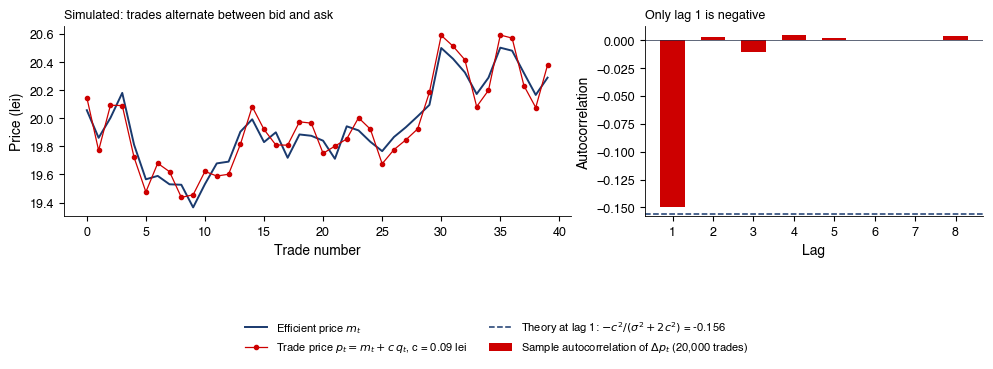

{'acf1': -0.150029822472831, 'rho': -0.15576923076923077}

In [7]:
# Solution
def a1_roll(var=0.0520, cov=-0.0081, price=20.0, rho_q=0.3):
    """The Roll model: moments, the estimator and its bias when trade signs are autocorrelated.
    With Corr(q_t, q_{t-1}) = rho_q (Markov chain, m independent of q): Cov(dp_t, dp_{t-1}) = -c^2 (1 - rho_q)^2."""
    c = np.sqrt(-cov)
    cov_rho = -c ** 2 * (1 - rho_q) ** 2
    return dict(c=c, s=2 * c, s_pct=100 * 2 * c / price, sig2=var - 2 * c ** 2, share=2 * c ** 2 / var,
                rho=cov / var, var=var, cov=cov, price=price, rho_q=rho_q, cov_rho=cov_rho,
                c_roll_rho=np.sqrt(-cov_rho), bias_pct=100 * rho_q)


def fig_a1_bounce(c=0.09, sig2=0.0358, n_path=40, n_long=20000, seed=SEED):
    """A1 simulated: efficient price, trade price and autocorrelation of changes, with the parameters of A1 sub-task 2."""
    rng = np.random.default_rng(seed)
    m = 20 + np.cumsum(rng.normal(0, np.sqrt(sig2), n_long))
    q = np.where(rng.random(n_long) < 0.5, 1, -1)
    p = m + c * q
    dp = np.diff(p)
    dm = dp - dp.mean()
    acf = [float(np.mean(dm[k:] * dm[:-k]) / np.mean(dm ** 2)) for k in range(1, 9)]
    rho = -c ** 2 / (sig2 + 2 * c ** 2)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw=dict(width_ratios=[1.5, 1]))
    ax = axes[0]
    k = np.arange(n_path)
    ax.plot(k, m[:n_path], color=MainBlue, lw=1.4, label='Efficient price $m_t$')
    ax.plot(k, p[:n_path], color=IDAred, lw=0.9, marker='o', ms=3, label='Trade price $p_t = m_t + c\\,q_t$, c = 0.09 lei')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Price (lei)')
    ax.set_title('Simulated: trades alternate between bid and ask', fontsize=9, loc='left')
    ax = axes[1]
    lags = np.arange(1, 9)
    ax.bar(lags, acf, color=IDAred, width=0.6, label=f'Sample autocorrelation of $\\Delta p_t$ ({n_long:,} trades)')
    ax.axhline(rho, color=MainBlue, ls='--', lw=1.1, label=f'Theory at lag 1: $-c^2/(\\sigma^2 + 2c^2)$ = {rho:.3f}')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Only lag 1 is negative', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.14, 1, 1))
    save_fig('ch10_sem_a1_bounce')
    return dict(acf1=acf[0], rho=rho)


print(a1_roll())
fig_a1_bounce()

### A2. Precision of the Roll Estimator [Proposed]

**Worked example to follow**: A1

**Question**: How much does the sample size $T$ matter for one Roll estimate, holding the population moments fixed?

**Context and assumptions**

- Population moments of A1: $\gamma_0 = 0.0520$, $\gamma_1 = -0.0081$, so $c = 0.090$, $s = 0.18$ lei; estimator $\hat s = 2\sqrt{-\hat\gamma_1}$ [Harris (1990)](https://doi.org/10.1111/j.1540-6261.1990.tb03704.x)
- $T$ = number of price changes; Gaussian approximation (Bartlett, MA(1)): $T\,\mathrm{Var}(\hat\gamma_1) \to \gamma_0^2 + 3\gamma_1^2$
- Delta method: for a smooth function $g$, $\mathrm{se}(g(\hat\theta)) \approx |g'(\theta)|\,\mathrm{se}(\hat\theta)$ (first-order Taylor expansion); $\Phi$: distribution function of the standard Normal distribution

**Sub-tasks**

1. Derive $g'(\gamma_1)$ for $g(\gamma_1) = 2\sqrt{-\gamma_1}$ and write $\mathrm{se}(\hat s)$ by the delta method.
2. Fill the table below for $T = 78$ and $T = 250$ price changes.
3. Approximate $P(\hat\gamma_1 > 0)$ with the Normal distribution and explain why binary signs and demeaning make the approximation rough.

**Report and interpret**

- the completed table
- how often would a true Roll market show a positive covariance in one sample of 78 changes?

In [ ]:
# Your code here


### A3. Glosten–Milgrom for Any Prior [Solved]

**Questions**

- How wide is the spread when the market maker learns from order flow?
- When is it widest?

**Context and assumptions**

- $V \in \{V_L, V_H\}$, $\Delta V = V_H - V_L$; $\mathcal{F}_t$ = the trades observed so far, $\theta = P(V = V_H \mid \mathcal{F}_t)$ [Glosten & Milgrom (1985)](https://doi.org/10.1016/0304-405X(85)90044-3)
- Likelihoods: $P(\text{buy} \mid V_H) = (1 + \mu)/2$, $P(\text{buy} \mid V_L) = (1 - \mu)/2$ (informed share $\mu$, uninformed buy or sell with probability 1/2)
- Pre-trade quotes for the next trade: $a = \mathbb{E}[V \mid \mathcal{F}_t, \text{buy}]$, $b = \mathbb{E}[V \mid \mathcal{F}_t, \text{sell}]$; $V_L = 90$, $V_H = 110$, $\mu = 0.3$

**Sub-tasks**

1. At $\theta = 0.5$, compute $P(V_H \mid \text{buy})$, the ask, the bid and the spread.
2. After one buy, the posterior becomes the new $\theta$: compute the next-trade quotes and spread.
3. Derive the spread for any $0 < \theta < 1$ and show that it is largest at $\theta = 1/2$; check it at $\theta = 0.7$.
4. Extension: show that $\mathbb{E}[\text{next trade price} \mid \mathcal{F}_t] = \mathbb{E}[V \mid \mathcal{F}_t]$ and that beliefs are a martingale.

**Report and interpret**

- the quotes, the spread formula and the martingale argument
- why is the spread largest when the market maker is most uncertain?

{'ask': 103.0, 'bid': 97.0, 'spread': 6.0, 'pb_h': 0.6499999999999999, 'pb_l': 0.35, 'th_b': 0.65, 'th_s': 0.35000000000000003, 'ask2': 105.5045871559633, 'bid2': 100.0, 'spread2': 5.504587155963307, 'th_b2': 0.7752293577981652, 'spread_07': 5.11363636363636, 'formula_07': 5.113636363636363, 'formula_05': 6.0}


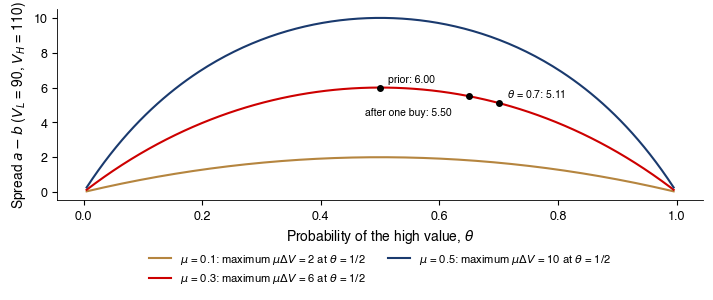

In [9]:
# Solution
def gm_spread_formula(theta, mu, dv=20.0):
    """Glosten-Milgrom spread for general theta: a - b = 4 mu theta (1 - theta) dV / (1 - mu^2 (2 theta - 1)^2)."""
    return 4 * mu * theta * (1 - theta) * dv / (1 - mu ** 2 * (2 * theta - 1) ** 2)


def a3_gm(mu=0.3, theta=0.5, vl=90.0, vh=110.0):
    ask, bid, tb, ts = gm_quotes(theta, mu, vl, vh)
    ask2, bid2, tb2, ts2 = gm_quotes(tb, mu, vl, vh)          # after one buy
    a7, b7, _, _ = gm_quotes(0.7, mu, vl, vh)
    return dict(ask=ask, bid=bid, spread=ask - bid, pb_h=mu + (1 - mu) / 2, pb_l=(1 - mu) / 2, th_b=tb, th_s=ts,
                ask2=ask2, bid2=bid2, spread2=ask2 - bid2, th_b2=tb2, spread_07=a7 - b7,
                formula_07=gm_spread_formula(0.7, mu, vh - vl), formula_05=gm_spread_formula(0.5, mu, vh - vl))


def fig_a3_spread(dv=20.0):
    """A3: the Glosten-Milgrom spread as a function of the prior probability theta, for three shares mu."""
    th = np.linspace(0.005, 0.995, 200)
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    for mu, c in [(0.1, Amber), (0.3, IDAred), (0.5, MainBlue)]:
        ax.plot(th, gm_spread_formula(th, mu, dv), color=c, lw=1.5, label=f'$\\mu$ = {mu}: maximum $\\mu\\Delta V$ = {mu * dv:.0f} at $\\theta$ = 1/2')
    for t_, lab in [(0.5, 'prior'), (0.65, 'after one buy'), (0.7, '$\\theta$ = 0.7')]:
        v = gm_spread_formula(t_, 0.3, dv)
        ax.plot(t_, v, 'o', color='black', ms=4)
        ax.annotate(f'{lab}: {v:.2f}', (t_, v), xytext=(6, 4) if t_ != 0.65 else (-75, -14), textcoords='offset points',
                    fontsize=7.5, color='black')
    ax.set_xlabel('Probability of the high value, $\\theta$')
    ax.set_ylabel('Spread $a - b$ ($V_L$ = 90, $V_H$ = 110)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save_fig('ch10_sem_a3_spread')


print(a3_gm())
fig_a3_spread()

### A4. How Fast Does the Market Maker Learn? [Proposed]

**Worked example to follow**: A3

**Questions**

- How many consecutive buys does it take before the bid exceeds 108?
- How does this number depend on $\mu$?

**Context and assumptions**

- A3 with $\theta_0 = 1/2$, $V_L = 90$, $V_H = 110$; true value $V_H$; a **conditioned scenario**: every trade is a buy, not the expected learning time
- Timeline: after $k$ buys the belief is $\theta_k$; the bid quoted then conditions on a hypothetical next sell

**Sub-tasks**

1. Show that each buy multiplies the odds $\theta/(1 - \theta)$ by $(1 + \mu)/(1 - \mu)$ and each sell divides them by the same factor.
2. Show that the bid after $k$ buys is $V_L + \Delta V\,\theta_{k-1}$.
3. Show that bid $> 108$ requires odds above 9, derive $k_{\min} = \lfloor \ln 9/\ln\frac{1 + \mu}{1 - \mu}\rfloor + 2$, ($\lfloor \cdot \rfloor$: integer part), and evaluate it for $\mu = 0.1, 0.3, 0.5$, checking the boundary case.
4. Compare with the simulated paths of the lecture, where uninformed traders also sell.

**Report and interpret**

- the three values of $k_{\min}$ and a plot of the bid against $k$
- how does the speed of price discovery depend on the share of informed traders?

In [ ]:
# Your code here


### A5. Deriving the Kyle Equilibrium [Solved]

**Questions**

- How aggressively does an insider trade?
- How much does the market maker move the price per share?

**Context and assumptions**

- Timeline: (1) the insider sees $v \sim N(p_0, \sigma_v^2)$ and sends $x$; (2) noise traders send $u \sim N(0, \sigma_u^2)$, independent; (3) the market maker sees only $y = x + u$ and sets $p = \mathbb{E}[v \mid y]$ [Kyle (1985)](https://doi.org/10.2307/1913210)
- Units: $v$, $p$ in USD; $x$, $u$, $y$ in shares; $\beta$ in shares per USD; $\lambda$ in USD per share. Numbers: $\sigma_v = 2$, $\sigma_u = 10 000$ and $20 000$

**Sub-tasks**

1. Insider best response: given $p = p_0 + \lambda y$, maximise the expected profit and write $\beta$ in $x = \beta(v - p_0)$.
2. Market-maker pricing: given $x = \beta(v - p_0)$, derive $\lambda$ from the projection theorem.
3. Solve the two equations; compute the expected profit, $\mathrm{Var}(x)$ and $\mathrm{Var}(v \mid y)$.
4. Fill a two-column table ($\sigma_u = 10 000$ and $20 000$): $\beta$, $\lambda$, profit, price change for $y = 15 000$.

**Report and interpret**

- the equilibrium formulas and the table
- why does more noise trading help the insider?

In [11]:
# Solution
def a5_kyle(sigma_v=2.0, sigma_u=10_000.0, y=15_000.0, sigma_u2=20_000.0):
    k = kyle(sigma_v, sigma_u)
    k2 = kyle(sigma_v, sigma_u2)
    k.update(sigma_v=sigma_v, sigma_u=sigma_u, y=y, dp=k['lam'] * y, lam100=100 * k['lam'],
             lam2=k2['lam'], profit2=k2['profit'], beta2=k2['beta'])
    return k


a5_kyle()

{'beta': 5000.0,
 'lam': 0.0001,
 'profit': 10000.0,
 'post_var': 2.0,
 'sigma_v': 2.0,
 'sigma_u': 10000.0,
 'y': 15000.0,
 'dp': 1.5,
 'lam100': 0.01,
 'lam2': 5e-05,
 'profit2': 20000.0,
 'beta2': 10000.0}

### A6. Kyle's Lambda as a Regression Slope [Proposed]

**Worked example to follow**: A5

**Questions**

- What does an Amihud-type ratio estimate in a Kyle economy?
- Does the choice of volume denominator matter?

**Context and assumptions**

- A5 with $p_0 = 50$ USD, $\sigma_v = 2$, $\sigma_u = 10 000$; simulation (seed 42): 200 000 independent auctions, $v = p_0 + \sigma_v z_1$, $u = \sigma_u z_2$, $x = \beta(v - p_0)$, $y = x + u$, $p = p_0 + \lambda y$, with $z_1$, $z_2$ independent standard Normal draws
- $|x| + |u|$ is a constructed gross-order proxy (the two orders counted separately), not exchange volume

**Sub-tasks**

1. Show that the population OLS slopes of $p - p_0$ and of $v - p_0$ on $y$ both equal $\lambda$, and give $\mathrm{Var}(y)$.
2. Show that $|r|/(p_0|y|)$, with $r = (p - p_0)/p_0$, equals $\lambda/p_0^2$, and convert it to bp per USD 1 million (factor $10^4 \times 10^6$).
3. Replace $|y|$ by $|x| + |u|$, derive the direction of the bias and measure it by simulation; repeat with $\sigma_u = 20 000$.

**Report and interpret**

- the slopes, the ratio for both denominators and both noise levels
- what does the Amihud ratio measure in a Kyle world?
- why is it biased with gross volume?

In [ ]:
# Your code here


### A7. Almgren–Chriss Execution [Solved]

**Questions**

- How should a risk-averse seller split 1 million shares over five days?
- What does the risk reduction cost?

**Context and assumptions**

- Parameters [Almgren & Chriss (2001)](https://doi.org/10.21314/JOR.2001.041): $X = 10^6$ shares, $T = 5$ days, $N = 5$, $\tau = 1$; $\sigma = 0.95$ USD per day$^{1/2}$; temporary impact $\eta = 2.5 \cdot 10^{-6}$, permanent $\gamma = 2.5 \cdot 10^{-7}$ (USD per share per share); risk aversion $\lambda = 2 \cdot 10^{-6}$ per USD
- $x_k$ = holdings after trade $k$ ($x_0 = X$, $x_5 = 0$), $n_k = x_{k-1} - x_k$; $\mathbb{E}[C] = \tfrac12\gamma X^2 + \frac{\tilde\eta}{\tau}\sum_{k=1}^{5} n_k^2$, $\mathrm{Var}[C] = \sigma^2\tau\sum_{k=1}^{5} x_k^2$, $\tilde\eta = \eta - \gamma\tau/2$

**Sub-tasks**

1. Compute $\tilde\eta$, $\tilde\kappa^2 = \lambda\sigma^2/\tilde\eta$ and $\kappa$ from $\cosh(\kappa\tau) = 1 + \tilde\kappa^2\tau^2/2$.
2. Fill a table of $k$, $x_k = X\sinh(\kappa(5 - k))/\sinh(5\kappa)$ and $n_k$.
3. Compute $\mathbb{E}[C]$ and $\mathrm{sd}[C]$ and compare with selling evenly ($\lambda = 0$).
4. Extension: minimise $\int_0^T(\eta\dot x^2 + \lambda\sigma^2x^2)\,dt$ with $x(0) = X$, $x(T) = 0$ by Euler–Lagrange and compare $\kappa_c$ with $\kappa$.

**Report and interpret**

- the schedule table, the cost–risk comparison and the holdings plot
- what does the trader buy with the extra expected cost?

{'lam': 2e-06, 'eta_t': 2.375e-06, 'kt2': 0.7599999999999999, 'kappa': np.float64(0.8462971345012561), 'kc': np.float64(0.84970583144992), 'kc2': np.float64(0.7219999999999998), 'x': [np.float64(1000000.0), np.float64(428598.8457470175), np.float64(182932.81426176784), np.float64(76295.7216154617), np.float64(27643.377396906417), np.float64(0.0)], 'xc': [np.float64(1000000.0), np.float64(427150.5440083748), np.float64(181711.71734401002), np.float64(75554.81028917071), np.float64(27310.618862276795), np.float64(0.0)], 'n': [np.float64(571401.1542529825), np.float64(245666.03148524964), np.float64(106637.09264630613), np.float64(48652.344218555285), np.float64(27643.377396906417)], 'E': np.float64(1078215.167049785), 'sd': np.float64(449367.65254135116), 'E0': np.float64(600000.0), 'sd0': np.float64(1040672.8592598157), 'sinh5': np.float64(34.402434282285846)}


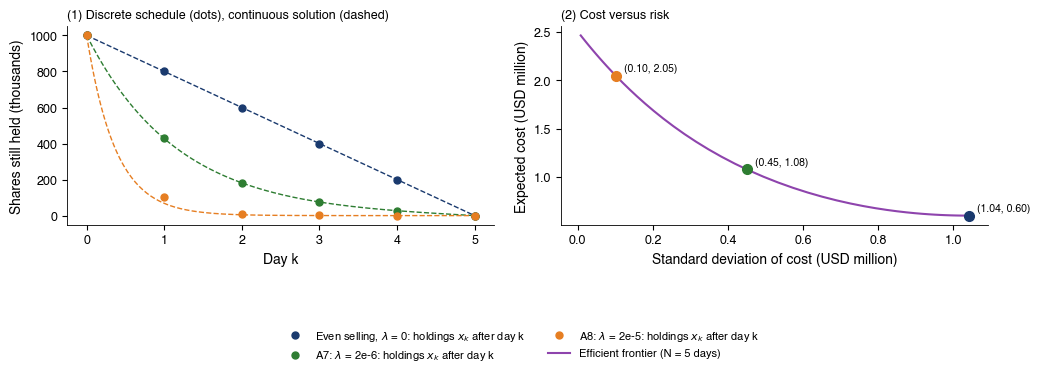

In [13]:
# Solution
def a7_ac(lam=2e-6):
    """Almgren-Chriss: the continuous-time solution (Euler-Lagrange: x'' = kappa^2 x) and the exact discrete schedule."""
    tau = AC['T'] / AC['N']
    eta_t = AC['eta'] - AC['gamma'] * tau / 2
    kt2 = lam * AC['sigma'] ** 2 / eta_t
    kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
    kc = np.sqrt(lam * AC['sigma'] ** 2 / AC['eta'])          # continuous time: eta_tilde -> eta as tau -> 0
    t, x, E, V = ac_trajectory(lam=lam, **AC)
    t0, x0, E0, V0 = ac_trajectory(lam=0, **AC)
    xc = AC['X'] * np.sinh(kc * (AC['T'] - t)) / np.sinh(kc * AC['T'])
    return dict(lam=lam, eta_t=eta_t, kt2=kt2, kappa=kappa, kc=kc, kc2=kc ** 2, x=list(x), xc=list(xc),
                n=list(-np.diff(x)), E=E, sd=np.sqrt(V), E0=E0, sd0=np.sqrt(V0), sinh5=np.sinh(5 * kappa))


def fig_ac_seminar():
    """A7-A8: holdings x_k after each day (discrete, N = 5) and the continuous solution; the cost - risk frontier."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
    ax = axes[0]
    tt = np.linspace(0, AC['T'], 200)
    pts = {}
    for lam, c, lab in [(0, MainBlue, 'Even selling, $\\lambda$ = 0'), (2e-6, Forest, 'A7: $\\lambda$ = 2e-6'),
                        (2e-5, Orange, 'A8: $\\lambda$ = 2e-5')]:
        t, x, E, V = ac_trajectory(lam=lam, **AC)
        pts[lam] = (E, np.sqrt(V))
        ax.plot(t, x / 1e3, color=c, lw=0, marker='o', ms=5, label=lab + ': holdings $x_k$ after day k')
        if lam > 0:
            kc = np.sqrt(lam * AC['sigma'] ** 2 / AC['eta'])
            ax.plot(tt, AC['X'] * np.sinh(kc * (AC['T'] - tt)) / np.sinh(kc * AC['T']) / 1e3, color=c, lw=1, ls='--')
        else:
            ax.plot(tt, AC['X'] * (1 - tt / AC['T']) / 1e3, color=c, lw=1, ls='--')
    ax.set_xlabel('Day k')
    ax.set_ylabel('Shares still held (thousands)')
    ax.set_title('(1) Discrete schedule (dots), continuous solution (dashed)', fontsize=9, loc='left')
    ax = axes[1]
    fr = ac_frontier(lams=np.logspace(-8, -3.5, 60), **AC)
    ax.plot(fr['sd'] / 1e6, fr['E'] / 1e6, color=Purple, lw=1.5, label='Efficient frontier (N = 5 days)')
    for lam, c in [(0, MainBlue), (2e-6, Forest), (2e-5, Orange)]:
        E, sd = pts[lam]
        ax.plot(sd / 1e6, E / 1e6, 'o', color=c, ms=7)
        ax.annotate(f'({sd / 1e6:.2f}, {E / 1e6:.2f})', (sd / 1e6, E / 1e6), xytext=(6, 3), textcoords='offset points',
                    fontsize=7.5, color='black')
    ax.set_xlabel('Standard deviation of cost (USD million)')
    ax.set_ylabel('Expected cost (USD million)')
    ax.set_title('(2) Cost versus risk', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.14, 1, 1))
    save_fig('ch10_sem_ac')


print(a7_ac())
fig_ac_seminar()

### A8. A More Risk-Averse Seller [Proposed]

**Worked example to follow**: A7

**Question**: How does the schedule change when risk aversion is ten times higher?

**Context and assumptions**

- A7 parameters: $X = 10^6$, $T = N = 5$, $\sigma = 0.95$, $\eta = 2.5 \cdot 10^{-6}$, $\gamma = 2.5 \cdot 10^{-7}$; only $\lambda$ changes, to $2 \cdot 10^{-5}$

**Sub-tasks**

1. Compute $\tilde\kappa^2$, $\kappa$, $\kappa_c$ and the holdings $x_k$.
2. Compute $\mathbb{E}[C]$ and $\mathrm{sd}[C]$ and the ratios new/A7, with their direction.
3. Overlay the holdings of A7 and A8 on one chart.
4. Optional: explain why $\kappa$ and $\kappa_c$ now differ much more.

**Report and interpret**

- one comparison table and the chart
- when would a trader choose this schedule?

In [ ]:
# Your code here


### A9. The PIN Likelihood, Step by Step [Solved]

**Questions**

- How do we evaluate the likelihood of one day of buys and sells without numerical overflow?
- What does it say about that day?

**Context and assumptions**

- EKOP [Easley et al. (1996)](https://doi.org/10.1111/j.1540-6261.1996.tb04074.x), three states: no news, prob. $1 - \alpha$, $(B, S) \sim$ Poisson$(\varepsilon_b)$, Poisson$(\varepsilon_s)$; bad news, $\alpha\delta$, sells rate $\mu + \varepsilon_s$; good news, $\alpha(1 - \delta)$, buys rate $\mu + \varepsilon_b$
- $\alpha = 0.3$, $\delta = 0.5$, $\mu = 400$, $\varepsilon_b = \varepsilon_s = 1 000$; one day with $B = 1 450$, $S = 1 000$

**Sub-tasks**

1. Write the likelihood as a three-component mixture and compute $\mathrm{PIN} = \alpha\mu/(\alpha\mu + \varepsilon_b + \varepsilon_s)$.
2. Explain why evaluating the terms directly fails in double precision.
3. Write each weighted log component, combine them as $m + \ln\sum e^{\ell_j - m}$ with $m = \max_j \ell_j$, and normalise the same components into posterior probabilities.

**Report and interpret**

- PIN, $\ln L$, the three posterior probabilities
- is the posterior probability of good news the same thing as PIN?

{'pin': 0.05660377358490566, 'naive': 'nan', 'exp_small': 0.0, 'loglik': -11.711088639429818, 'p_none': np.float64(3.1706463847436303e-38), 'p_bad': np.float64(1.7473662565978968e-66), 'p_good': np.float64(1.0), 'B': 1450, 'S': 1000, 'alpha': 0.3, 'delta': 0.5, 'mu': 400.0, 'eb': 1000.0, 'es': 1000.0}


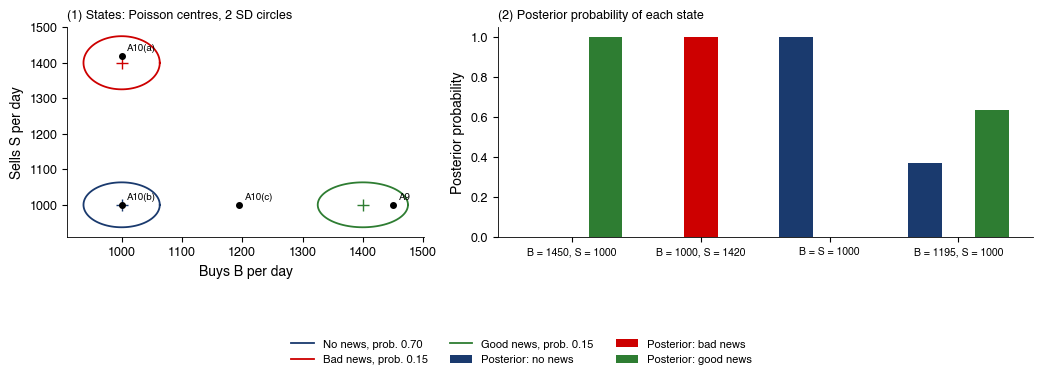

{'A9: B = 1450, S = 1000': [3.1706463847436303e-38,
  1.7473662565978968e-66,
  1.0],
 'A10(a): B = 1000, S = 1420': [7.673418400353384e-34,
  1.0,
  4.228876625930984e-62],
 'A10(b): B = S = 1000': [1.0, 5.511072647538979e-29, 5.511072647538979e-29],
 'A10(c): B = 1195, S = 1000': [0.3672859873996508,
  2.0241397589825613e-29,
  0.6327140126003492]}

In [15]:
# Solution
def pin_posterior(B, S, alpha, delta, mu, eb, es):
    """Posterior probabilities of the three states (no news, bad news, good news) given (B, S)."""
    from scipy.special import softmax
    _, terms = pin_loglik(B, S, alpha, delta, mu, eb, es)
    return softmax(terms)


def a9_pin(B=1450, S=1000, **par):
    """EKOP likelihood of one day: direct evaluation fails numerically, the factorised form does not."""
    import warnings as _w
    par = par or PIN_PAR
    a, d, mu, eb, es = (par[k] for k in ('alpha', 'delta', 'mu', 'eb', 'es'))
    pin = a * mu / (a * mu + eb + es)
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        naive = np.exp(-eb) * np.float64(eb) ** B                 # e^-1000 = 0 and 1000^1450 = inf: 0 * inf = nan
    ll, _ = pin_loglik(B, S, a, d, mu, eb, es)
    post = pin_posterior(B, S, a, d, mu, eb, es)
    return dict(pin=pin, naive=str(naive), exp_small=float(np.exp(-eb)), loglik=ll, p_none=post[0], p_bad=post[1],
                p_good=post[2], B=B, S=S, **par)


def fig_pin(**par):
    """A9-A10: the three states of the EKOP model (Poisson centres) and the posterior probabilities for four days."""
    par = par or PIN_PAR
    a, d_, mu, eb, es = (par[k] for k in ('alpha', 'delta', 'mu', 'eb', 'es'))
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), gridspec_kw=dict(width_ratios=[1, 1.5]))
    ax = axes[0]
    th = np.linspace(0, 2 * np.pi, 100)
    for (bx, sx), lab, c in [((eb, es), f'No news, prob. {1 - a:.2f}', MainBlue),
                             ((eb, es + mu), f'Bad news, prob. {a * d_:.2f}', IDAred),
                             ((eb + mu, es), f'Good news, prob. {a * (1 - d_):.2f}', Forest)]:
        ax.plot(bx + 2 * np.sqrt(bx) * np.cos(th), sx + 2 * np.sqrt(sx) * np.sin(th), color=c, lw=1.3, label=lab)
        ax.plot(bx, sx, '+', color=c, ms=8)
    for lab, B_, S_ in PIN_DAYS:
        ax.plot(B_, S_, 'o', color='black', ms=4)
        ax.annotate(lab.split(':')[0], (B_, S_), xytext=(4, 4), textcoords='offset points', fontsize=7, color='black')
    ax.set_xlabel('Buys B per day')
    ax.set_ylabel('Sells S per day')
    ax.set_title('(1) States: Poisson centres, 2 SD circles', fontsize=9, loc='left')
    ax = axes[1]
    post = {}
    xs = np.arange(len(PIN_DAYS))
    w = 0.26
    for j, (lab_, c) in enumerate([('No news', MainBlue), ('Bad news', IDAred), ('Good news', Forest)]):
        vals = []
        for lab, B_, S_ in PIN_DAYS:
            pp = pin_posterior(B_, S_, a, d_, mu, eb, es)
            post[lab] = [float(v) for v in pp]
            vals.append(pp[j])
        ax.bar(xs + (j - 1) * w, vals, w, color=c, label=f'Posterior: {lab_.lower()}')
    ax.set_xticks(xs)
    ax.set_xticklabels([l.split(': ')[1] for l, _, _ in PIN_DAYS], fontsize=7.5)
    ax.set_ylabel('Posterior probability')
    ax.set_title('(2) Posterior probability of each state', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.13, 1, 1))
    save_fig('ch10_sem_pin')
    return post


print(a9_pin())
fig_pin()

### A10. Reading Days with the PIN Model [Proposed]

**Worked example to follow**: A9

**Questions**

- How confidently can known PIN parameters classify a day?
- What changes when the parameters are unknown?

**Context and assumptions**

- The A9 parameters; two observed days (a) $B = 1 000$, $S = 1 420$; (b) $B = S = 1 000$; (c) a hypothetical ambiguous day, $B = 1 195$, $S = 1 000$

**Sub-tasks**

1. For each day, compute the stable log-likelihood and the three posterior probabilities.
2. Compute PIN when $\mu$ doubles to 800.
3. Conceptual: explain why estimating $(\alpha, \delta, \mu, \varepsilon_b, \varepsilon_s)$ from many days remains hard for very liquid stocks.

**Report and interpret**

- a table of days by posterior probabilities, and the new PIN
- can an order imbalance always be read as private information?

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. The Intraday U-Shape of SPY [Solved]

**Questions**

- Are volatility and volume systematically higher at the open and the close?
- Is the pattern driven by a few extreme days?

**Context and assumptions**

- SPY 5-minute bars, 1 477 full days (see the Data section above); $|r|$ in bp; bars are labelled by their start time
- One row per day: $|r|$ of the first bar (09:30), the mean $|r|$ of the 31 midday bars starting 11:30 to 14:00 inclusive, and the share of the day's volume in the last six bars

**Sub-tasks**

1. Compute the ratio of the cross-day means, $\overline{|r|}_{\text{open}}/\overline{|r|}_{\text{mid}}$, and the mean last-30-minute volume share.
2. Build 95% day-bootstrap intervals for both statistics (1 000 resamples of complete rows, seed 42).
3. Plot mean $|r|$ and the mean volume share by bar with pointwise day-bootstrap bands.

**Report and interpret**

- the two estimates with intervals and the two profiles
- why resample days rather than bars?
- what does the pattern imply for a trader who must buy 1 million shares today?

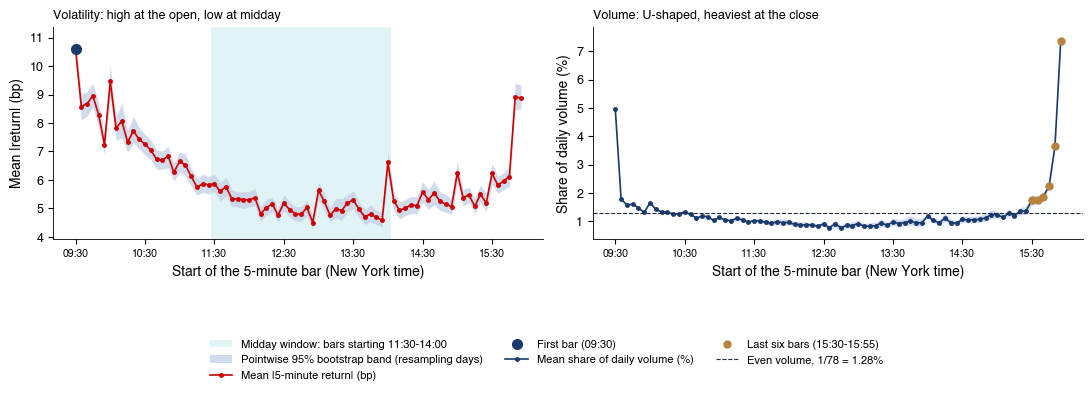

{'ratio': np.float64(2.0611100241206155),
 'lo': 1.9800262772534618,
 'hi': 2.154720227869524,
 'open': np.float64(10.590414985574784),
 'mid': np.float64(5.138209441338895),
 'vshare': np.float64(18.64671431741261),
 'vlo': 18.32366443924597,
 'vhi': 18.985597110968445,
 'n': 1477,
 'absr_close': 8.879817050739323,
 'n_mid_bars': 31,
 'first': {'ratio': 2.134893526465308,
  'n_unique': 933,
  'open': 10.685590593589126,
  'mid': 5.005210077750809,
  'vshare': 18.61406680509396}}

In [17]:
# Solution
def b1_ushape():
    s = intraday_spy()
    x = s.dropna(subset=['r'])
    by_day = {}
    for d, g in x.groupby('date'):
        g = g.set_index('tod')
        by_day[d] = (abs(g['r'].get('09:30', np.nan)), g.loc['11:30':'14:00', 'r'].abs().mean(),
                     g['volume'].iloc[-6:].sum() / g['volume'].sum())
    arr = np.array(list(by_day.values()))
    ratio = np.nanmean(arr[:, 0]) / np.nanmean(arr[:, 1])
    lo, hi = boot_days(by_day, lambda v: np.nanmean([a[0] for a in v]) / np.nanmean([a[1] for a in v]))
    vs = np.nanmean(arr[:, 2])
    vlo, vhi = boot_days(by_day, lambda v: np.nanmean([a[2] for a in v]))
    tod = spy_tod(s)
    # one bootstrap step, explicitly: the first resample (same generator as boot_days)
    rng1 = np.random.default_rng(SEED)
    days = np.array(list(by_day.keys()))
    pick = rng1.choice(days, len(days), replace=True)
    a1 = np.array([by_day[d] for d in pick])
    first = dict(ratio=float(np.nanmean(a1[:, 0]) / np.nanmean(a1[:, 1])), n_unique=int(len(np.unique(pick))),
                 open=float(1e4 * np.nanmean(a1[:, 0])), mid=float(1e4 * np.nanmean(a1[:, 1])),
                 vshare=float(100 * np.nanmean(a1[:, 2])))
    # chart: mean |r| and share of the day's volume by interval, with pointwise day-bootstrap bands
    piv = x.pivot_table(index='date', columns='tod', values='r', aggfunc=lambda v: abs(v).mean())
    vsh = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby([s['date'], s['tod']]).sum().unstack()
    rng = np.random.default_rng(SEED)
    bs = np.array([piv.iloc[rng.integers(0, len(piv), len(piv))].mean().values for _ in range(300)])
    lo_b, hi_b = 1e4 * np.nanpercentile(bs, 2.5, axis=0), 1e4 * np.nanpercentile(bs, 97.5, axis=0)
    rng = np.random.default_rng(SEED + 1)
    bv = np.array([vsh.iloc[rng.integers(0, len(vsh), len(vsh))].mean().values for _ in range(300)])
    lo_v, hi_v = 100 * np.percentile(bv, 2.5, axis=0), 100 * np.percentile(bv, 97.5, axis=0)
    k = np.arange(len(piv.columns))
    cols = list(piv.columns)
    i0, i1 = cols.index('11:30'), cols.index('14:00')
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    ax = axes[0]
    ax.axvspan(i0 - 0.5, i1 + 0.5, color=Teal, alpha=0.12, lw=0, label='Midday window: bars starting 11:30-14:00')
    ax.fill_between(k, lo_b, hi_b, color='#C5D2E8', alpha=0.8, lw=0, label='Pointwise 95% bootstrap band (resampling days)')
    ax.plot(k, 1e4 * piv.mean().values, color=IDAred, lw=1.2, marker='o', ms=2.5, label='Mean |5-minute return| (bp)')
    ax.plot(0, 1e4 * piv.mean().values[0], 'o', color=MainBlue, ms=7, label='First bar (09:30)')
    ax.set_xticks(k[::12])
    ax.set_xticklabels(cols[::12], fontsize=7.5)
    ax.set_xlabel('Start of the 5-minute bar (New York time)')
    ax.set_ylabel('Mean |return| (bp)')
    ax.set_title('Volatility: high at the open, low at midday', fontsize=9, loc='left')
    ax = axes[1]
    ax.fill_between(k, lo_v, hi_v, color='#C5D2E8', alpha=0.8, lw=0)
    ax.plot(k, 100 * vsh.mean().values, color=MainBlue, lw=1.2, marker='o', ms=2.5, label='Mean share of daily volume (%)')
    ax.plot(k[-6:], 100 * vsh.mean().values[-6:], 'o', color=Amber, ms=5, label='Last six bars (15:30-15:55)')
    ax.axhline(100 / 78, color=Gray, lw=0.8, ls='--', label='Even volume, 1/78 = 1.28%')
    ax.set_xticks(k[::12])
    ax.set_xticklabels(cols[::12], fontsize=7.5)
    ax.set_xlabel('Start of the 5-minute bar (New York time)')
    ax.set_ylabel('Share of daily volume (%)')
    ax.set_title('Volume: U-shaped, heaviest at the close', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.13, 1, 1))
    save_fig('ch10_sem_ushape')
    return dict(ratio=ratio, lo=lo, hi=hi, open=1e4 * np.nanmean(arr[:, 0]), mid=1e4 * np.nanmean(arr[:, 1]),
                vshare=100 * vs, vlo=100 * vlo, vhi=100 * vhi, n=len(by_day), absr_close=float(tod['absr'].iloc[-1]),
                n_mid_bars=int(i1 - i0 + 1), first=first)


b1_ushape()

### B2. Spread Estimators at Two Frequencies [Solved]

**Question**: Which sampling frequency gives a credible bid-ask spread for SPY, the most traded ETF?

**Context and assumptions**

- Intraday: the 1 477 days of SPY 5-minute bars; per day 78 closes give 77 log returns
- Daily: SPY daily bars, 19 Sep 2024 – 18 Sep 2026 (501 days); one tick = USD 0.01
- Recipes (log prices; all spreads relative)
- Roll: per day the demeaned lag-1 autocovariance of the 77 returns, averaged over days, then $2\sqrt{-\bar\gamma_1}$, set to 0 if $\bar\gamma_1 \ge 0$ [Roll (1984)](https://doi.org/10.1111/j.1540-6261.1984.tb03897.x)
- Corwin–Schultz: the two-bar estimate for each pair of consecutive bars (negatives set to 0), averaged; daily bars add the overnight adjustment [Corwin & Schultz (2012)](https://doi.org/10.1111/j.1540-6261.2012.01729.x)
- Abdi–Ranaldo: the mean of $4(c_t - \eta_t)(c_t - \eta_{t+1})$, then the square root, 0 if negative [Abdi & Ranaldo (2017)](https://doi.org/10.1093/rfs/hhx084)

**Sub-tasks**

1. Compute the three estimators from the 5-minute bars with 95% day-bootstrap intervals (resample precomputed daily moment rows, not prices).
2. Repeat on the same two-year window as the daily bars, so that only the frequency differs.
3. Compute the three estimators from daily bars with a moving-block bootstrap (blocks of 20 days, 1 000 resamples), and report how often each is truncated at 0.
4. Compare every estimate with one tick relative to the price, a floor for the quoted (not the effective) spread.
5. Simulate the Roll model with SPY's bar variance, 78 prices a day, 1 477 days per sample, 200 samples, for $c$ = one tick and $c = 0$; compute the share of days with $\hat\gamma_1 > 0$ and the pooled estimate [Harris (1990)](https://doi.org/10.1111/j.1540-6261.1990.tb03704.x).
6. Correct the pooled 5-minute Roll estimate for the demeaning bias $\mathbb{E}[\hat\gamma_1] \approx \gamma_1 - (\gamma_0 + 2\gamma_1)/77$.

**Report and interpret**

- an interval plot of the estimates, the truncation shares, and the Monte Carlo results next to the observed ones
- which frequency gives a credible spread?
- what do the daily estimators measure?
- is the share of positive covariances evidence against Roll?

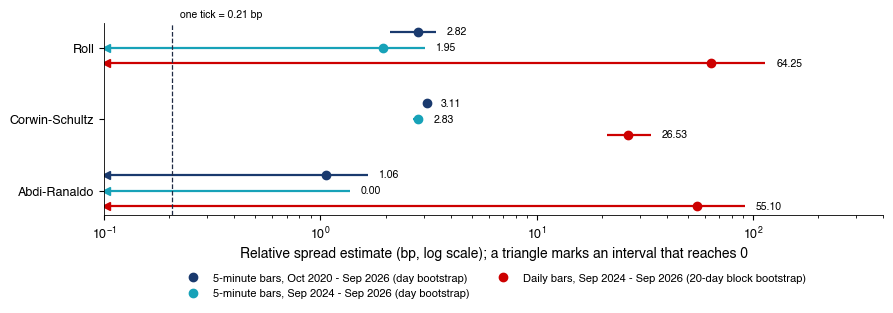

{'roll5': np.float64(2.8178694948515814),
 'rlo': 2.088525758122144,
 'rhi': 3.4255275546874655,
 'cs5': np.float64(3.114235796578178),
 'clo': 3.0289837140441427,
 'chi': 3.2013723971846377,
 'ar5': np.float64(1.0597709930490853),
 'alo': 0.0,
 'ahi': 1.667760884627947,
 'tick': np.float64(0.2065684865019977),
 'cs_d': np.float64(26.531990252599034),
 'cs_dlo': 21.267107513278532,
 'cs_dhi': 33.72329018189908,
 'ar_d': np.float64(55.09545779283073),
 'ar_dlo': 0.0,
 'ar_dhi': 92.17863018512608,
 'sd_daily': 103.3794289113439,
 'share_negcov': 0.5924170616113744,
 'roll_d': 64.25381258330147,
 'roll_dlo': 0.0,
 'roll_dhi': 114.43412214595969,
 'roll_d_pos': 0.097,
 'trunc_roll5': 0.0,
 'trunc_ar5': 0.112,
 'trunc_ar_d': 0.034,
 'trunc_roll_d': 0.097,
 'n_days5': 1477,
 'n_daily': 501,
 'n_ret5': 77,
 'n_days5m': 496,
 'roll5m': 1.947729143865,
 'cs5m': 2.8267272540140413,
 'ar5m': 0.0,
 'roll5mlo': 0.0,
 'roll5mhi': 3.0549445227034644,
 'cs5mlo': 2.6795327658870285,
 'cs5mhi': 2.972165

In [18]:
# Solution
def b2_spreads():
    s = intraday_spy()
    E = intraday_spreads(s)
    by_day = {d: row for d, row in E.iterrows()}
    roll5 = 1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0))
    rlo, rhi = boot_days(by_day, lambda v: 1e4 * 2 * np.sqrt(max(-np.mean([r['cov'] for r in v]), 0)))
    cs5 = 1e4 * E['cs'].mean()
    clo, chi = boot_days(by_day, lambda v: 1e4 * np.mean([r['cs'] for r in v]))
    ar5 = 1e4 * np.sqrt(max(E['ar2'].mean(), 0))
    alo, ahi = boot_days(by_day, lambda v: 1e4 * np.sqrt(max(np.mean([r['ar2'] for r in v]), 0)))
    tick = 1e4 * (0.01 / E['price']).mean()
    # daily data: moving-block bootstrap with blocks of 20 days
    d = ohlc('SPY', START2)
    cs = cs_spread(d['high'], d['low'], d['close'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    dp = np.diff(np.log(d['close'].values))
    pairs = np.column_stack([dp[1:], dp[:-1]])                # pairs (dp_t, dp_{t-1}) for the Roll covariance
    roll_cov = lambda x: np.mean(x[:, 0] * x[:, 1]) - x[:, 0].mean() * x[:, 1].mean()
    rng = np.random.default_rng(SEED)
    n, L = len(cs), 20
    csb, arb, rlb = [], [], []
    for _ in range(B):
        st = rng.integers(0, n - L + 1, n // L + 1)             # possible block starts: 0, ..., n - L
        idx = np.concatenate([np.arange(a, a + L) for a in st])[:n]
        csb.append(1e4 * cs[idx].mean())
        arb.append(1e4 * np.sqrt(max(ar2[idx].mean(), 0)))
        ip = np.minimum(idx, len(pairs) - 1)
        rlb.append(roll_cov(pairs[ip]))
    rlb = np.array(rlb)
    roll_d = 1e4 * 2 * np.sqrt(max(-roll_cov(pairs), 0))
    rlb_s = 1e4 * 2 * np.sqrt(np.maximum(-rlb, 0))
    sd_daily = 1e4 * np.log(d['close']).diff().std()
    res = dict(roll5=roll5, rlo=rlo, rhi=rhi, cs5=cs5, clo=clo, chi=chi, ar5=ar5, alo=alo, ahi=ahi, tick=tick,
               cs_d=1e4 * cs.mean(), cs_dlo=float(np.percentile(csb, 2.5)), cs_dhi=float(np.percentile(csb, 97.5)),
               ar_d=1e4 * np.sqrt(max(ar2.mean(), 0)), ar_dlo=float(np.percentile(arb, 2.5)),
               ar_dhi=float(np.percentile(arb, 97.5)), sd_daily=sd_daily, share_negcov=float((E['cov'] < 0).mean()),
               roll_d=float(roll_d), roll_dlo=float(np.percentile(rlb_s, 2.5)), roll_dhi=float(np.percentile(rlb_s, 97.5)),
               roll_d_pos=float((rlb >= 0).mean()))
    # how often each estimator is truncated at 0 across resamples (the averaged moment has the wrong sign)
    _, _, mc = boot_days(by_day, lambda v: np.mean([r['cov'] for r in v]), draws=True)
    _, _, ma = boot_days(by_day, lambda v: np.mean([r['ar2'] for r in v]), draws=True)
    res.update(trunc_roll5=float((mc >= 0).mean()), trunc_ar5=float((ma <= 0).mean()),
               trunc_ar_d=float((np.array(arb) == 0).mean()), trunc_roll_d=float((rlb >= 0).mean()),
               n_days5=int(len(E)), n_daily=int(len(d)), n_ret5=int(s.dropna(subset=['r']).groupby('date').size().iloc[0] - 1))
    # the same two-year window for the 5-minute bars (sensitivity: frequency without the period effect)
    Em = E.loc[START2:]
    bm = {dd: row for dd, row in Em.iterrows()}
    res.update(n_days5m=int(len(Em)),
               roll5m=float(1e4 * 2 * np.sqrt(max(-Em['cov'].mean(), 0))),
               cs5m=float(1e4 * Em['cs'].mean()), ar5m=float(1e4 * np.sqrt(max(Em['ar2'].mean(), 0))))
    res['roll5mlo'], res['roll5mhi'] = boot_days(bm, lambda v: 1e4 * 2 * np.sqrt(max(-np.mean([r['cov'] for r in v]), 0)))
    res['cs5mlo'], res['cs5mhi'] = boot_days(bm, lambda v: 1e4 * np.mean([r['cs'] for r in v]))
    res['ar5mlo'], res['ar5mhi'] = boot_days(bm, lambda v: 1e4 * np.sqrt(max(np.mean([r['ar2'] for r in v]), 0)))
    fig_b2_estimates(res)
    return res


b2_spreads()

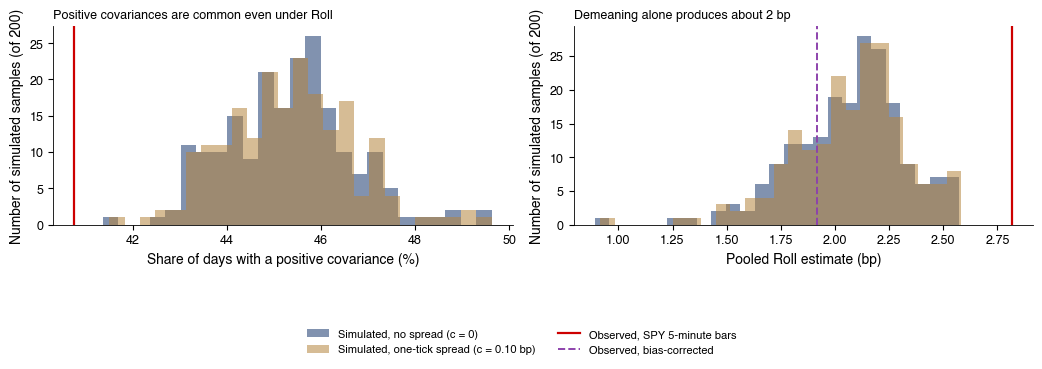

{'pos_tick': 0.45316181448882875,
 'pos_zero': 0.4533243060257279,
 'roll_tick': 2.0730377581893937,
 'roll_zero': 2.0625393126665523,
 'obs_pos': 0.4075829383886256,
 'obs_roll': 2.8178694948515814,
 'roll_corr': 1.9180237793613462,
 'var_bar': 8.387469309162364e-07,
 'n': 77,
 'n_days': 1477}

In [19]:
# Solution, sub-tasks 5-6: Monte Carlo of the Roll model (Harris, 1990)
roll_small_sample(intraday_spreads(intraday_spy()))


def b2_mc(E):
    """Monte Carlo under the Roll model, calibrated to SPY (same settings as roll_small_sample): distributions of the
    share of days with a positive covariance and of the pooled Roll estimate, for a one-tick spread and no spread."""
    n = 77
    v = E['var'].mean()
    c_tick = (0.01 / E['price']).mean() / 2
    obs_pos = float((E['cov'] > 0).mean())
    obs_roll = float(1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0)))
    g1 = (E['cov'].mean() + v / n) / (1 - 2 / n)
    corr = float(1e4 * 2 * np.sqrt(max(-g1, 0)))
    sims = {}
    for tag, c in [('tick', c_tick), ('zero', 0.0)]:
        sig = np.sqrt(v - 2 * c ** 2)
        cov = np.array([roll_mc(c, sig, T=n + 1, R=len(E), seed=SEED + b) for b in range(200)])
        sims[tag] = dict(pos=(cov > 0).mean(axis=1), pooled=1e4 * 2 * np.sqrt(np.clip(-cov.mean(axis=1), 0, None)))
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
    for ax, key, xl, obs in [(axes[0], 'pos', 'Share of days with a positive covariance (%)', 100 * obs_pos),
                             (axes[1], 'pooled', 'Pooled Roll estimate (bp)', obs_roll)]:
        sc = 100 if key == 'pos' else 1
        for tag, c, lab in [('zero', MainBlue, 'Simulated, no spread (c = 0)'),
                            ('tick', Amber, f'Simulated, one-tick spread (c = {1e4 * c_tick:.2f} bp)')]:
            ax.hist(sc * sims[tag][key], bins=25, color=c, alpha=0.55, label=lab)
        ax.axvline(obs, color=IDAred, lw=1.6, label='Observed, SPY 5-minute bars')
        if key == 'pooled':
            ax.axvline(corr, color=Purple, lw=1.4, ls='--', label='Observed, bias-corrected')
        ax.set_xlabel(xl)
        ax.set_ylabel('Number of simulated samples (of 200)')
    axes[0].set_title('Positive covariances are common even under Roll', fontsize=9, loc='left')
    axes[1].set_title('Demeaning alone produces about 2 bp', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + [h2[-1]], l1 + [l2[-1]], ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.14, 1, 1))
    save_fig('ch10_sem_b2_mc')
    return dict(pos_tick=float(sims['tick']['pos'].mean()), pos_zero=float(sims['zero']['pos'].mean()),
                roll_tick=float(sims['tick']['pooled'].mean()), roll_zero=float(sims['zero']['pooled'].mean()),
                obs_pos=obs_pos, obs_roll=obs_roll, roll_corr=corr, var_bar=float(v), n=n, n_days=int(len(E)))


b2_mc(intraday_spreads(intraday_spy()))

### B3. Spread Estimates Across 25 Assets [Proposed]

**Worked example to follow**: B2

**Questions**

- Do daily spread proxies rank BVB stocks as liquid as US stocks?
- Does the Amihud ratio agree?

**Context and assumptions**

- The 25 assets listed in the Data section above: 7 US, 10 BVB stocks plus the BET ETF (11), 7 crypto; daily bars, 19 Sep 2024 – 18 Sep 2026
- Estimators as in B2 (daily recipes); volatility annualised with 252 days (stocks) or 365 (crypto); Amihud in bp per USD 1 million, crypto volume already in USD, BVB converted at the BNR rate

**Sub-tasks**

1. Compute Corwin–Schultz and Abdi–Ranaldo for each asset, and the median of each estimator in each group.
2. Count, per group, the assets for which Abdi–Ranaldo is set to 0.
3. Compute the Spearman correlations of Corwin–Schultz with volatility, of Amihud with the median traded value, and of Corwin–Schultz with Amihud, and draw the three scatter plots.

**Report and interpret**

- a table with rows US, BVB, crypto and columns Corwin–Schultz median, Abdi–Ranaldo median, Abdi–Ranaldo zeros; the three correlations and plots
- which measure would you trust to compare markets?
- what would you need to validate it?

In [ ]:
# Your code here


### B4. Illiquidity and the VIX [Solved]

**Questions**

- By how much does SPY's intraday illiquidity rise when implied volatility rises?
- How precise is that elasticity?

**Context and assumptions**

- $\mathrm{ILLIQ}_d = \frac{1}{78}\sum_{k} 10^4|r_{d,k}|/(\mathrm{DV}_{d,k}/10^8)$: bp per USD 100 million, from the 5-minute bars of day $d$, $k = 1, \dots, 78$ ($r_{d,k}$: log return, $\mathrm{DV}_{d,k}$ = close $\times$ volume; $10^4$ converts to bp, $10^8$ to USD 100 million); bars with zero value dropped
- Aligned on trading days with the close of the VIX index: 1 477 days, 2020-10-12 – 2026-09-18; mean $\mathrm{ILLIQ}$ 1.83

**Sub-tasks**

1. Estimate $\ln\mathrm{ILLIQ}_d = a + b\ln\mathrm{VIX}_d + e_d$ by OLS ($b$: elasticity, the % change in illiquidity for a 1% higher VIX; $e_d$: error) and plot the fit.
2. Plot the residual autocorrelations; report OLS and HAC (Newey–West, 20 lags) standard errors and the 95% HAC interval [Newey & West (1987)](https://doi.org/10.2307/1913610).
3. Extension: add a linear trend $t$ (in years from the first day) and re-estimate $b$.
4. Extension: with $D_d = 1$ from 2023-09-27 (the middle of the sample, fixed before estimation), add $gD_d + hD_d\ln\mathrm{VIX}_d$ ($h$: change in the elasticity after the break) and test $h = 0$ with a HAC Wald test at 5%.

**Report and interpret**

- a table of specifications ($\hat b$, SE, interval) and the coefficient plot
- why do the two standard errors differ?
- is the elasticity stable?
- is the relation causal?

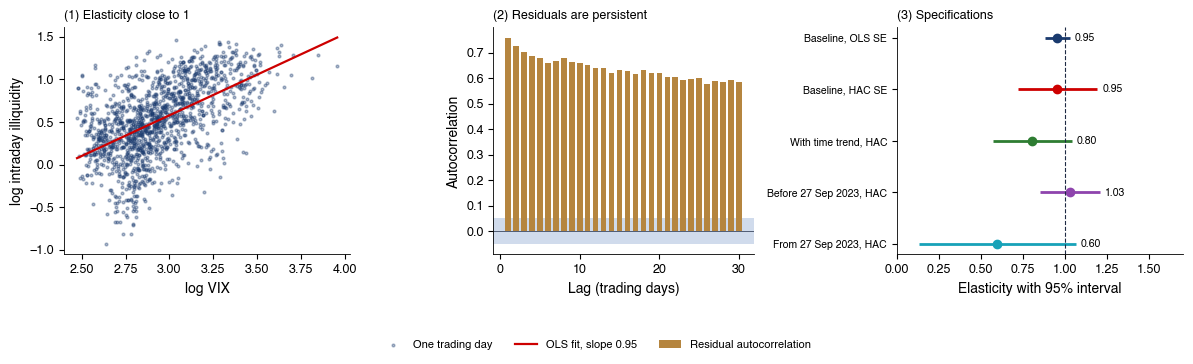

{'se_post': 0.23792780260621466,
 'wald': 2.8988116145613536,
 'se_pre': 0.08994005798972952,
 'a': -2.285283288165777,
 'illiq_mean': 1.8339556993864106,
 'vix_mean': 19.473276912660797,
 'start': '2020-10-12',
 'end': '2026-09-18',
 'b': 0.9544304059527832,
 'se_ols': 0.03762559414053015,
 'se_hac': 0.12116131927996482,
 'brk': '2023-09-27',
 'b_pre': 1.029337759489565,
 'b_post': 0.5962705134490079,
 'd_brk': -0.433067246040557,
 'se_brk': 0.25435796505618935,
 'p_brk': 0.08864488292106393,
 'lo': 0.7169542201640522,
 'hi': 1.1919065917415141,
 'r2': 0.30373962833787016,
 'n': 1477,
 'rho1': 0.7589592718584635,
 'b2': 0.8042733818184661,
 'se2': 0.12031769162600765,
 'trend': -0.0616845891503183,
 'se_trend': 0.021082133375156693}

In [21]:
# Solution
def b4_illiq_vix():
    s = intraday_spy()
    ill = spy_illiq_daily(s)
    vix = read_market('VIX.INDX')['close'].rename('vix')
    j = pd.concat([ill, vix], axis=1, join='inner').dropna()
    y, X = np.log(j['illiq']), sm.add_constant(np.log(j['vix']))
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    # control for the level of traded value (trend)
    dvd = s.groupby('date')['dv'].sum().rename('dv')
    j2 = pd.concat([j, dvd], axis=1, join='inner').dropna()
    X2 = sm.add_constant(pd.DataFrame({'lvix': np.log(j2['vix']), 't': np.arange(len(j2)) / 252}))
    hac2 = sm.OLS(np.log(j2['illiq']), X2).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    rho1 = float(np.corrcoef(ols.resid[1:], ols.resid[:-1])[0, 1])
    # sub-task 4, elasticity stability: break at the middle of the sample (date fixed before estimation), HAC Wald test
    mid = j.index[len(j) // 2]
    post = (j.index >= mid).astype(float)
    X3 = sm.add_constant(pd.DataFrame({'lvix': np.log(j['vix']), 'post': post, 'lvix_post': post * np.log(j['vix'])},
                                      index=j.index))
    hac3 = sm.OLS(y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    w = hac3.wald_test('lvix_post = 0', scalar=True)
    cv3 = hac3.cov_params()
    se_post = float(np.sqrt(cv3.loc['lvix', 'lvix'] + cv3.loc['lvix_post', 'lvix_post'] + 2 * cv3.loc['lvix', 'lvix_post']))
    fig_b4(j, ols, hac, hac2, hac3, se_post, mid)
    return dict(se_post=se_post, wald=float(w.statistic), se_pre=float(hac3.bse['lvix']), a=float(hac.params.iloc[0]),
                illiq_mean=float(j['illiq'].mean()), vix_mean=float(j['vix'].mean()),
                start=j.index[0].strftime('%Y-%m-%d'), end=j.index[-1].strftime('%Y-%m-%d'), b=float(hac.params.iloc[1]), se_ols=float(ols.bse.iloc[1]), se_hac=float(hac.bse.iloc[1]),
                brk=mid.strftime('%Y-%m-%d'), b_pre=float(hac3.params['lvix']),
                b_post=float(hac3.params['lvix'] + hac3.params['lvix_post']), d_brk=float(hac3.params['lvix_post']),
                se_brk=float(hac3.bse['lvix_post']), p_brk=float(w.pvalue),
                lo=float(hac.params.iloc[1] - 1.96 * hac.bse.iloc[1]), hi=float(hac.params.iloc[1] + 1.96 * hac.bse.iloc[1]),
                r2=float(ols.rsquared), n=int(len(j)), rho1=rho1, b2=float(hac2.params['lvix']),
                se2=float(hac2.bse['lvix']), trend=float(hac2.params['t']), se_trend=float(hac2.bse['t']))


b4_illiq_vix()

### B5. Amihud Illiquidity on Three Markets [Proposed]

**Worked example to follow**: B2, B3

**Questions**

- How many times less liquid is the BVB than the US by the Amihud ratio?
- How precise is that multiple?
- How stable is it?

**Context and assumptions**

- The 25 assets of B3 (BVB includes the BET ETF); fixed group membership
- Aggregation: average the daily ratios within each asset over 19 Sep 2024 – 18 Sep 2026, then take the group median
- Years: 19 Sep 2024 – 18 Sep 2025 and 19 Sep 2025 – 18 Sep 2026

**Sub-tasks**

1. Compute the three group medians and the ratio BVB median / US median.
2. Build a 95% interval by resampling assets with replacement independently within each group (1 000 resamples), recomputing the median ratio each time.
3. Compute the Spearman correlation of the asset rankings in the two years.

**Report and interpret**

- the medians, the ratio with its interval, the rank correlation and log-scale plots
- what does the interval condition on?
- is illiquidity a stable asset characteristic?

In [ ]:
# Your code here


### B6. Volume and Price Moves in SPY Bars [Solved]

**Questions**

- How do absolute returns scale with relative volume in 5-minute bars?
- Can that slope be read as a price-impact law?

**Context and assumptions**

- SPY 5-minute bars with positive volume: 115 052 bars on 1 477 days (115 206 bars minus 154 without volume)
- Relative volume $v$ = bar volume / median volume at the same time of day; $z = |r|/\sigma_{\text{day}}$, $\sigma_{\text{day}}$ the SD of that day's 5-minute returns

**Sub-tasks**

1. Sort bars into 20 equal-size groups by $v$ (bin edges fixed on the full sample), regress $\ln\bar z$ on $\ln\bar v$ ($\bar z$, $\bar v$: group means), and give a 95% day-bootstrap interval (300 resamples, same edges).
2. At bar level, estimate $\ln(|r| + 10^{-6}) - \ln\sigma_{\text{day}} = a + b\ln v + e$ with SEs clustered by day, test $b = 0.5$, and repeat without the bars with $r = 0$.
3. Extension: instrument $\ln v$ by the log relative volume of the same bar on the previous trading day; report the first stage and the slope estimated by two-stage least squares (2SLS), with clustered SE.

**Report and interpret**

- the grouped fit, the four slope estimates with intervals and the first stage
- is the relation concave?
- is it the square-root law [Tóth et al. (2011)](https://doi.org/10.1103/PhysRevX.1.021006)?
- is the exclusion restriction plausible?

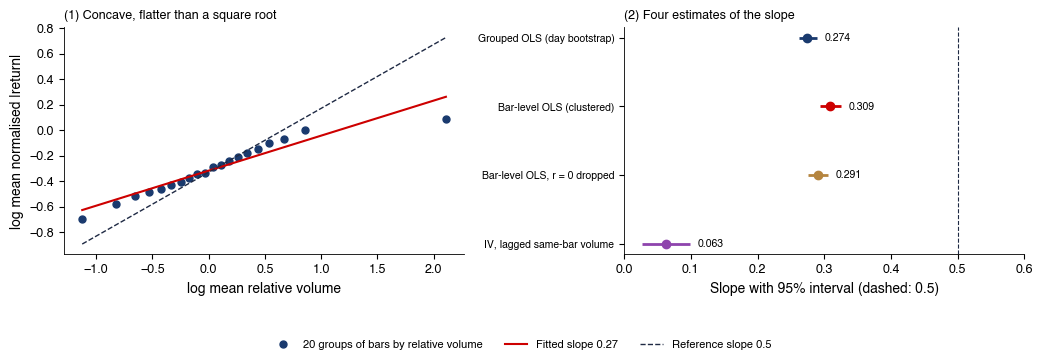

{'slope': 0.2741805378202134,
 'lo': 0.2615504642483289,
 'hi': 0.28929374285577375,
 'n': 115052,
 'n_days': 1477,
 'raw': 0.30916679954290216,
 'raw_se': 0.007894481991039768,
 'zero_share': 0.007683482251503615,
 'raw_nz': 0.29090810366111325,
 'raw_nz_se': 0.007614247781602145,
 'fs': 0.33892084364726316,
 'fs_t': 32.78652152889044,
 'iv': 0.06268299972220037,
 'iv_se': 0.01810321201506867,
 'n_iv': 114974,
 'corr_absr_lag': 0.0433724147607286}

In [23]:
# Solution
def b6_sqrt():
    s = intraday_spy()
    x, g, slope, _ = sqrt_relation(s)
    days = x['date'].unique()
    by = {d: grp for d, grp in x.groupby('date')}
    bins = np.quantile(x['part'], np.linspace(0, 1, 21))
    rng = np.random.default_rng(SEED)
    sl = []
    for _ in range(300):
        pick = rng.choice(days, len(days), replace=True)
        xx = pd.concat([by[d] for d in pick])
        gg = xx.groupby(pd.cut(xx['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean')).dropna()
        sl.append(np.polyfit(np.log(gg['v']), np.log(gg['z']), 1)[0])
    lo, hi = np.percentile(sl, [2.5, 97.5])
    # on individual bars (not groups)
    y = np.log(x['r'].abs() + 1e-6) - np.log(x.groupby('date')['r'].transform('std'))
    raw = sm.OLS(y, sm.add_constant(np.log(x['part']))).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(x['date'])[0]})
    # zero returns: ln|r| is undefined; constant 1e-6 (0.01 bp) and, as a sensitivity check, dropping bars with r = 0
    nz = (x['r'] != 0).values
    raw_nz = sm.OLS(y[nz], sm.add_constant(np.log(x['part'][nz]))).fit(cov_type='cluster',
                                                                       cov_kwds={'groups': pd.factorize(x['date'][nz])[0]})
    # sub-task 3, instrumental variable: relative volume of the same bar (same time of day) on the previous day
    x = x.assign(ly=y, lv=np.log(x['part']))
    x['lv_lag'] = x.groupby('tod')['lv'].shift(1)             # bars are in time order; a shift within the time of day = the previous day
    x['ly_lag'] = x.groupby('tod')['ly'].shift(1)
    z = x.dropna(subset=['lv_lag', 'ly_lag'])
    gid = pd.factorize(z['date'])[0]
    fs = sm.OLS(z['lv'], sm.add_constant(z['lv_lag'])).fit(cov_type='cluster', cov_kwds={'groups': gid})
    Z = sm.add_constant(z['lv_lag']).values
    Xe = sm.add_constant(z['lv']).values
    Pz = Z @ np.linalg.solve(Z.T @ Z, Z.T @ Xe)               # projection of the regressors on the instruments
    b_iv = np.linalg.solve(Pz.T @ Xe, Pz.T @ z['ly'].values)
    e = z['ly'].values - Xe @ b_iv
    A = np.linalg.inv(Pz.T @ Pz)
    meat = sum(np.outer(Pz[gid == gg].T @ e[gid == gg], Pz[gid == gg].T @ e[gid == gg]) for gg in np.unique(gid))
    se_iv = np.sqrt(np.diag(A @ meat @ A))
    red = np.corrcoef(z['ly'], z['ly_lag'])[0, 1]            # yesterday's |r| at the same time: the channel that violates exclusion
    fig_b6(g, slope, (lo, hi), raw, raw_nz, b_iv[1], se_iv[1])
    return dict(slope=float(slope), lo=float(lo), hi=float(hi), n=int(len(x)), n_days=int(len(days)),
                raw=float(raw.params.iloc[1]), raw_se=float(raw.bse.iloc[1]), zero_share=float(1 - nz.mean()),
                raw_nz=float(raw_nz.params.iloc[1]), raw_nz_se=float(raw_nz.bse.iloc[1]), fs=float(fs.params.iloc[1]),
                fs_t=float(fs.tvalues.iloc[1]), iv=float(b_iv[1]), iv_se=float(se_iv[1]), n_iv=int(len(z)),
                corr_absr_lag=float(red))


b6_sqrt()

### B7. The Bitcoin Clock [Proposed]

**Worked example to follow**: B1

**Question**: Does a market open 24/7 still keep the clock of traditional markets?

**Context and assumptions**

- Bitcoin 5-minute bars, UTC, 749 days (535 weekdays, 214 weekend days); returns spanning missing bars are discarded; coverage is incomplete: only 106 days have all 288 bars (minimum 26); all days are kept
- Weighting: first the mean $|r|$ of each day in a window (hours $[h_1, h_2)$), then the mean over days; ratios are ratios of these day means

**Sub-tasks**

1. On weekdays, compute the mean $|r|$ in 13:00–17:00 UTC and in 03:00–11:00 UTC and their ratio, with a 95% day-bootstrap interval.
2. Compute the weekday / weekend ratio of mean $|r|$ with a 95% day-bootstrap interval (days resampled from the pooled sample).
3. Plot the two hourly profiles with day-bootstrap bands.

**Report and interpret**

- the two ratios with intervals and the profiles
- what spread, depth and volume evidence would an execution decision need beyond volatility?

In [ ]:
# Your code here


### B8. Price Discovery: the BET ETF and BET-TR [Solved]

**Questions**

- Does the BET ETF or the BET-TR index lead price discovery?
- How sure can we be with daily closes?

**Context and assumptions**

- Log closes $y_t = (\ln P^{\mathrm{ETF}}_t, \ln P^{\mathrm{idx}}_t)'$ of Patria-TVBETETF (days with trades) and BET-TR, common days 2024-09-19 – 2026-09-18, 493 VECM observations; the ETF reinvests dividends; BET-TR is computed, not traded
- VECM: $\Delta y_t = a_0 + \alpha z_{t-1} + \sum_{i=1}^{p}\Gamma_i\Delta y_{t-i} + e_t$, $z_{t-1} = \ln P^{\mathrm{ETF}}_{t-1} - \ln P^{\mathrm{idx}}_{t-1}$, $\mathrm{Var}(e_t) = \Omega$; unrestricted constant; $p$ lags of the *differences*, chosen by BIC over 1–10 [Johansen (1991)](https://doi.org/10.2307/2938278)

**Sub-tasks**

1. Plot the rebased prices and the basis; run the Johansen trace test (rank one does not by itself establish $\beta = (1, -1)'$, which is imposed).
2. Estimate the VECM and test $\alpha_{\mathrm{ETF}} = 0$ and $\alpha_{\mathrm{idx}} = 0$ at 5%.
3. With $\alpha_\perp = (-\alpha_{\mathrm{idx}}, \alpha_{\mathrm{ETF}})'$ compute the component share $\alpha_\perp/\sum\alpha_\perp$ [Gonzalo & Granger (1995)](https://doi.org/10.1080/07350015.1995.10524576) and the information share $([\alpha_\perp' F]_j)^2/\alpha_\perp'\Omega\alpha_\perp$ for both Cholesky orderings, $F$ the lower-triangular factor with $FF' = \Omega$ and $[\cdot]_j$ the $j$-th element [Hasbrouck (1995)](https://doi.org/10.1111/j.1540-6261.1995.tb04054.x).
4. Bootstrap: resample moving blocks of 20 regression rows $(\Delta y_t, 1, z_{t-1}, \Delta y_{t-1}, \ldots)$, 1 000 times; then re-estimate $\alpha$ on each half.

**Report and interpret**

- the test, $\alpha$ with asymptotic and bootstrap intervals, the ordering bounds with endpoint intervals, the two halves
- which price leads?
- why are the bounds wide?
- why can the component share leave $[0, 1]$?

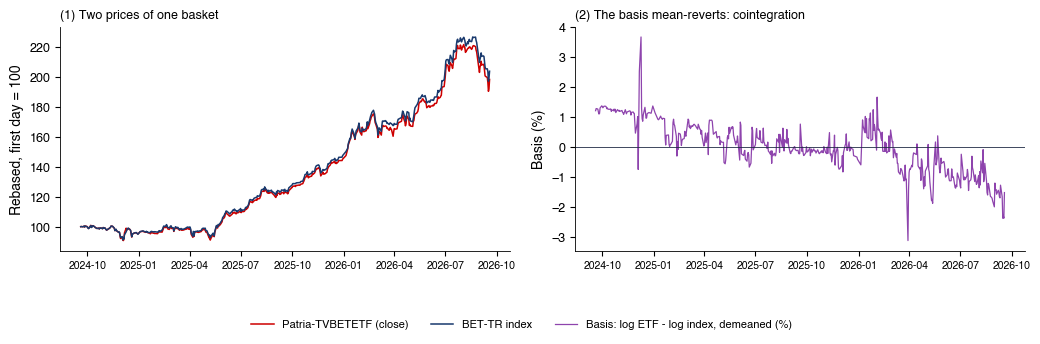

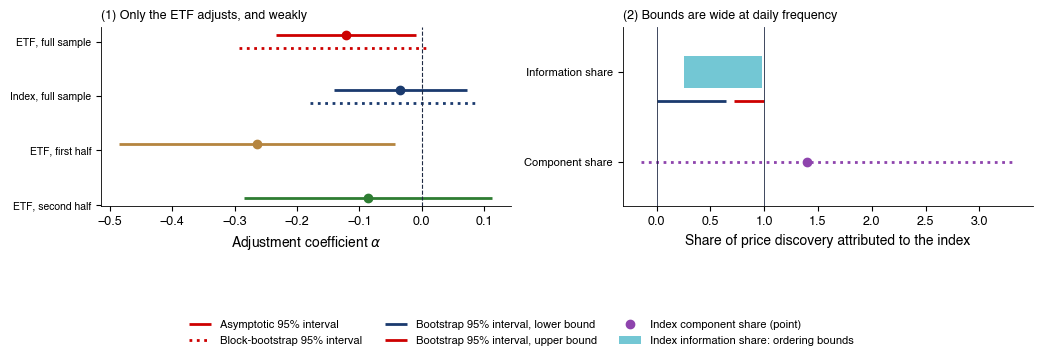

{'basis_mean': -724.4047423170958,
 'start': '2024-09-19',
 'end': '2026-09-18',
 'a_etf': -0.1214459102853011,
 'a_idx': -0.03428253008476459,
 't_etf': -2.1099805086951555,
 't_idx': -0.6336008319602243,
 'cs_idx': 1.393313453492635,
 'is_idx_lo': 0.2506303205818098,
 'is_idx_hi': 0.9774000124240595,
 'ci_a_etf': [-0.2935454011727737, 0.007610469736294262],
 'ci_a_idx': [-0.1789257458495205, 0.09119011636201929],
 'ci_cs_idx': [-0.14056426366042757, 3.324003541257161],
 'ci_is_lo': [0.00469437465834641, 0.6447464238224223],
 'ci_is_hi': [0.7202862311171911, 0.9997726639789694],
 'h1_a_etf': -0.2634961102572369,
 'h1_t_etf': -2.337134654848788,
 'h2_a_etf': -0.08606647810627799,
 'h2_t_etf': -0.8475282523918808,
 'h1_a_idx': -0.08448869371042537,
 'h2_a_idx': 0.04385152411372403,
 'h1_t_idx': -0.7690845357633991,
 'h2_t_idx': 0.4748021918555294,
 'corr': 0.9310847008895238,
 'n': 493,
 'p': 1,
 'trace': 49.638335176116335,
 'cv': 15.4943,
 'trace1': 0.10180446807762619,
 'cv1': 3.8415

In [25]:
# Solution
def b8_price_discovery(B=B, L=20, seed=SEED):
    """The Patria-TVBETETF and the BET-TR index: VECM with the vector (1, -1), Hasbrouck share bounds, the
    Gonzalo-Granger share; moving-block bootstrap intervals (blocks of L days) over the VECM pairs (X_t, Y_t);
    then the two halves of the sample."""
    from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order
    y = bet_etf_pair().values
    p = max(int(select_order(y, maxlags=10, deterministic='co').bic), 1)   # BIC over 1..10 lags of dy
    jo = coint_johansen(y, 0, p)                                           # unrestricted constant
    base = price_discovery(y, p)
    dy = np.diff(y, axis=0)
    z = (y[:, 0] - y[:, 1])[:-1]
    X = np.array([[1.0, z[t]] + [v for i in range(1, p + 1) for v in dy[t - i]] for t in range(p, len(dy))])
    Y = dy[p:]
    rng = np.random.default_rng(seed)
    n = len(Y)
    draws = []
    for _ in range(B):
        st = rng.integers(0, n - L + 1, n // L + 1)
        idx = np.concatenate([np.arange(a, a + L) for a in st])[:n]
        Xb, Yb = X[idx], Y[idx]
        Bb = np.linalg.lstsq(Xb, Yb, rcond=None)[0]
        U = Yb - Xb @ Bb
        Om = U.T @ U / (n - X.shape[1])
        al = Bb[1]
        ap = np.array([-al[1], al[0]])
        ISs = []
        for order in ([0, 1], [1, 0]):
            F = np.linalg.cholesky(Om[np.ix_(order, order)])
            v = (ap[order] @ F) ** 2 / (ap @ Om @ ap)
            ISs.append(v[np.argsort(order)][1])
        draws.append((al[0], al[1], ap[1] / ap.sum(), min(ISs), max(ISs)))
    d = np.array(draws)
    ci = lambda k: [float(x) for x in np.percentile(d[:, k], [2.5, 97.5])]
    half = len(y) // 2
    h1, h2 = price_discovery(y[:half], p), price_discovery(y[half:], p)
    fig_b8(bet_etf_pair(), base, d, h1, h2)
    return dict(basis_mean=float(100 * np.mean(y[:, 0] - y[:, 1])), start=bet_etf_pair().index[0].strftime('%Y-%m-%d'),
                end=bet_etf_pair().index[-1].strftime('%Y-%m-%d'), a_etf=float(base['alpha'][0]), a_idx=float(base['alpha'][1]), t_etf=float(base['t'][0]),
                t_idx=float(base['t'][1]), cs_idx=float(base['cs'][1]), is_idx_lo=float(base['is_lo'][1]),
                is_idx_hi=float(base['is_hi'][1]), ci_a_etf=ci(0), ci_a_idx=ci(1), ci_cs_idx=ci(2), ci_is_lo=ci(3),
                ci_is_hi=ci(4), h1_a_etf=float(h1['alpha'][0]), h1_t_etf=float(h1['t'][0]), h2_a_etf=float(h2['alpha'][0]),
                h2_t_etf=float(h2['t'][0]), h1_a_idx=float(h1['alpha'][1]), h2_a_idx=float(h2['alpha'][1]),
                h1_t_idx=float(h1['t'][1]), h2_t_idx=float(h2['t'][1]), corr=base['corr'], n=int(base['n']), p=p,
                trace=float(jo.lr1[0]), cv=float(jo.cvt[0, 1]), trace1=float(jo.lr1[1]), cv1=float(jo.cvt[1, 1]))


b8_price_discovery()

## Part C — project seeds and critique of an AI answer

### C1. Does Illiquidity Carry a Premium on the BVB? [Proposed]

**Worked example to follow**: B4, B5

**Questions**: Amihud (2002) predicts that illiquidity is priced [Amihud (2002)](https://doi.org/10.1016/S1386-4181(01)00024-6)

- Does expected illiquidity raise future returns on the BVB?
- Does an unexpected rise in illiquidity lower current returns?

**Context and assumptions**

- Markets: BVB (return BET-TR; illiquidity from the ten blue chips), US (SPY; six US stocks), crypto (Bitcoin; six other coins); monthly log returns in %, 2016–2026
- Index: mean daily Amihud ratio per asset-month ($\ge 10$ days); cross-sectional mean of its log, $L_t$; shock: residual of the AR(1) $L_t = \phi_0 + \phi L_{t-1} + v_t$, with $\hat\phi$ the estimated persistence and $T$ the number of months

**Sub-tasks**

1. Milestone 1: build the index and its shock for each market.
2. Milestone 2: estimate $r_t = a + b_1 L_{t-1} + b_2\,\mathrm{shock}_t + e_t$ with HAC SEs (6 lags); $r_t$: the market's monthly return; Amihud predicts $b_1 > 0$ (expected illiquidity is priced) and $b_2 < 0$ (an illiquidity shock lowers prices).
3. Milestone 3: correct $b_1$ for the Stambaugh bias [Stambaugh (1999)](https://doi.org/10.1016/S0304-405X(99)00041-0) (the small-sample bias of $\hat b_1$ when $L_t$ is persistent and its shocks are correlated with returns) with the reduced-bias estimator: $\hat\phi_c = \hat\phi + (1 + 3\hat\phi)/T + 3(1 + 3\hat\phi)/T^2$, residuals $v^c_t$ from $\hat\phi_c$, regress $r_t$ on $L_{t-1}$ and $v^c_t$, SE including the uncertainty of $\hat\phi_c$ [Amihud & Hurvich (2004)](https://doi.org/10.1017/S0022109000003227).
4. Milestone 4 (sorts): each January rank the blue chips with more than 150 trading days by the previous year's Amihud; hold equal-weighted illiquid and liquid halves for the year (monthly simple total returns); test the mean difference with HAC SEs.

**Report and interpret**

- a table per market, the reference charts and a discussion of power (few stocks, ten years) [Pele, Mazurencu-Marinescu & Nijkamp (2013)](https://doi.org/10.2139/ssrn.2305945)
- which of Amihud's two predictions survives on each market?

In [ ]:
# Your code here


### C2. Critique an AI Answer [Proposed]

**Worked example to follow**: A1, B2

**Questions**

- Which parts of the AI answer are wrong?
- How would you detect each error before using the numbers?

**Context and assumptions**

- A conceptual audit: no data file is needed; `P` and `V` are hypothetical
- Three checks to run first: the sign of the Roll covariance (A1), the units of the Amihud denominator (see the Notation slide of the seminar), the bid, mid and ask of a round trip

**Sub-tasks**

1. The answer contains three errors; identify each one in the text and, where applicable, in the code.
2. For each error, state how you would detect it: a test, a published number or a formula from today's primer.
3. Correct each error: give the formula, the code line and the corrected number where the information permits one; state the units of your Amihud ratio.
4. Log the errors you actually found in `AI_ERRORS.md`: request, answer, error, how found, correction.

**Report and interpret**

- the three errors with detection and correction
- which error would change an investment decision?

In [ ]:
# Your code here


### C3. The Price of the Speed Race in SPY [Proposed]

**Worked example to follow**: B1, B4

**Questions**: If the London latency-arbitrage tax applied to SPY

- How large would the prize be?
- How much would it move on stress days?

**Context and assumptions**

- Lecture case study [Aquilina, Budish & O'Neill (2022)](https://doi.org/10.1093/qje/qjab032): tax 0.419 bp (Table X); Table $\mathsf{XV}$: col. 2 $\Pi_t = 0.4213 \cdot 10^{-4}V_t$; col. 6 $\Pi_t = 10^{-4}(0.3354\,V_t + 0.0066\,\sigma_t\bar V)$; Table $\mathsf{XIV}$ scenarios 0.20–0.74 bp; SPY full days 2021–2025
- Units: $\Pi_t$, $V_t$ in USD; $V_t$ = sum of close $\times$ volume over the 78 bars; $\sigma_t = 100\sqrt{252\sum r^2}$ in %; $\bar V$ the mean of the year
- Outputs are implications of transferred coefficients, not measured US race profits

**Sub-tasks**

1. Daily inputs: compute $V_t$ and $\sigma_t$; report yearly means and the yearly correlation of $V_t$ and $\sigma_t$ with 95% intervals from an i.i.d. day bootstrap and a 20-day moving-block bootstrap; compare with the paper's 0.82.
2. Annual extrapolation: compute each year's prize $\sum_t\Pi_t$ under col. 2, col. 6 and the two scenarios.
3. Show that under col. 6 the annual tax is $0.3354 + 0.0066\,\bar\sigma$ bp and find the $\bar\sigma$ above which col. 6 exceeds col. 2.
4. Stress days: plot the tax at mean traded value, $0.3354 + 0.0066\,\sigma_t$, and the realised ratio $\Pi_t/V_t = 0.3354 + 0.0066\,\sigma_t\bar V/V_t$; work 7 April 2025 completely.

**Report and interpret**

- the annual table, the derivation and threshold, the daily chart and the worked day
- which assumptions carry a London 2015 tax over to SPY today?
- can the data at hand sign their effect?

In [ ]:
# Your code here
